In [8]:
# ============================================================
# FULL CELL (IMPROVED): HILL PRE-TRAINING + TUNING + WEIGHT TRANSFER
# + ADVANCED FINE-TUNING + GLOBAL BEST CHECKPOINT + TEST EVAL
# ============================================================

!pip install -q keras-tuner

import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import keras_tuner as kt

# -----------------------------
# Reproducibility
# -----------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("\n" + "="*70)
print("PHASE 0: CONFIG")
print("="*70)

# Data config
N_INPUTS      = 10
N_SYNTHETIC   = 500
X_MIN         = 0.1
X_MAX         = 100.0

# Hill-like target config
HILL_C1 = 3.8
HILL_C2 = 5.9
HILL_C3 = 0.0
HILL_K  = 0.26
HILL_N  = 1.8
HILL_D  = 4.2

# Splits
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15
assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-9

# Core training
PRETRAIN_EPOCHS = 80
TUNER_TRIALS    = 10
TUNER_EPOCHS    = 50
BATCH_SIZE      = 32

# Advanced fine-tuning config
USE_HUBER_LOSS = True
HUBER_DELTA    = 1.0

EPOCHS_S1 = 15   # head only
EPOCHS_S2 = 20   # last hidden + head
EPOCHS_S3 = 40   # full unfreeze

LR_S1 = 8e-4
LR_S2 = 3e-4
LR_S3 = 8e-5

CLIPNORM      = 1.0
USE_EMA       = True
EMA_MOMENTUM  = 0.99
WEIGHT_DECAY  = 1e-5

# Paths
BEST_CKPT_PATH = "best_finetuned_model.keras"

print(f"Seed: {RANDOM_SEED}")
print(f"Data: N={N_SYNTHETIC}, inputs={N_INPUTS}, splits={TRAIN_FRAC:.0%}/{VAL_FRAC:.0%}/{TEST_FRAC:.0%}")

# ============================================================
# PHASE 1: SYNTHETIC DATA
# ============================================================
print("\n" + "="*70)
print("PHASE 1: SYNTHETIC HILL DATA GENERATION")
print("="*70)

def generate_hill_data(
    n_samples, n_features, c1, c2, c3, k, n_hill, d, x_min, x_max,
    noise_frac=0.02, clip_percentile=99.0
):
    """
    y = c1*(n*x^(n-1)/(k^n + x^n)) + c2*x^d + c3 + small feature effects + noise
    """
    X = np.random.uniform(x_min, x_max, (n_samples, n_features)).astype(np.float32)
    x1 = X[:, 0]

    numerator = n_hill * np.power(x1, n_hill - 1.0)
    denominator = np.power(k, n_hill) + np.power(x1, n_hill)
    y = c1 * (numerator / denominator) + c2 * np.power(x1, d) + c3

    # Small effects from other features
    for i in range(1, min(n_features, 3)):
        y += 0.05 * (X[:, i] - x_min) / (x_max - x_min)

    # Robust noise scaling
    scale_ref = np.percentile(np.abs(y), clip_percentile)
    noise_std = noise_frac * max(scale_ref, 1e-8)
    y += np.random.normal(0.0, noise_std, size=n_samples)

    return X, y.reshape(-1, 1).astype(np.float32)

X_raw, y_raw = generate_hill_data(
    N_SYNTHETIC, N_INPUTS,
    HILL_C1, HILL_C2, HILL_C3, HILL_K, HILL_N, HILL_D,
    X_MIN, X_MAX, noise_frac=0.02
)

print(f"✓ Generated X: {X_raw.shape}, y: {y_raw.shape}")
print(f"  y range: [{y_raw.min():.3e}, {y_raw.max():.3e}]")

# ============================================================
# PHASE 2: SPLIT + SCALE
# ============================================================
print("\n" + "="*70)
print("PHASE 2: SPLIT + SCALING")
print("="*70)

# 70 / 30
X_train_raw, X_temp_raw, y_train_raw, y_temp_raw = train_test_split(
    X_raw, y_raw,
    test_size=(1.0 - TRAIN_FRAC),
    random_state=RANDOM_SEED
)

# 30 -> 15 / 15
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
    X_temp_raw, y_temp_raw,
    test_size=(TEST_FRAC / (VAL_FRAC + TEST_FRAC)),
    random_state=RANDOM_SEED
)

print(f"Raw splits -> train: {X_train_raw.shape}, val: {X_val_raw.shape}, test: {X_test_raw.shape}")

# Fit scalers only on train
scaler_X = StandardScaler().fit(X_train_raw)
scaler_y = StandardScaler().fit(y_train_raw)

X_train = scaler_X.transform(X_train_raw).astype(np.float32)
X_val   = scaler_X.transform(X_val_raw).astype(np.float32)
X_test  = scaler_X.transform(X_test_raw).astype(np.float32)

y_train = scaler_y.transform(y_train_raw).astype(np.float32)
y_val   = scaler_y.transform(y_val_raw).astype(np.float32)
y_test  = scaler_y.transform(y_test_raw).astype(np.float32)

print("✓ Scaling complete (train-fit only)")

# ============================================================
# PHASE 3: WARMUP PRE-TRAINING
# ============================================================
print("\n" + "="*70)
print("PHASE 3: WARMUP PRE-TRAINING")
print("="*70)

tf.keras.backend.clear_session()

def build_base_model(l2_val=1e-3, d1=0.2, d2=0.2, d3=0.1, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(N_INPUTS,)),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2_val), name="dense_128"),
        layers.Dropout(d1, name="drop_1"),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2_val), name="dense_64"),
        layers.Dropout(d2, name="drop_2"),
        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(l2_val), name="dense_32"),
        layers.Dropout(d3, name="drop_3"),
        layers.Dense(1, activation='linear', name="dense_out"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )
    return model

warmup_model = build_base_model()
print(f"✓ Warmup model params: {warmup_model.count_params():,}")

pre_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    callbacks.TerminateOnNaN()
]

hist_pre = warmup_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=PRETRAIN_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=pre_callbacks,
    verbose=1
)

print(f"✓ Pretrain best val_loss: {np.min(hist_pre.history['val_loss']):.6f}")

# ============================================================
# PHASE 4: TUNING (FIXED ARCHITECTURE)
# ============================================================
print("\n" + "="*70)
print("PHASE 4: HYPERPARAMETER TUNING")
print("="*70)

def build_model_fixed(hp):
    l2_val = hp.Choice('l2_reg', [1e-4, 1e-3, 1e-2])
    d1     = hp.Float('dropout_1', 0.0, 0.3, step=0.05)
    d2     = hp.Float('dropout_2', 0.0, 0.3, step=0.05)
    d3     = hp.Float('dropout_3', 0.0, 0.2, step=0.05)
    lr     = hp.Choice('lr', [1e-4, 5e-4, 1e-3, 5e-3])
    return build_base_model(l2_val=l2_val, d1=d1, d2=d2, d3=d3, lr=lr)

tuner = kt.RandomSearch(
    build_model_fixed,
    objective='val_loss',
    max_trials=TUNER_TRIALS,
    executions_per_trial=1,
    overwrite=True,
    directory='tuner_results',
    project_name='ann_70_15_15'
)

tuner_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    callbacks.TerminateOnNaN()
]

print(f"Starting tuner search ({TUNER_TRIALS} trials)...")
tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=TUNER_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=tuner_callbacks,
    verbose=1
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("\n✓ Best hyperparameters:")
for k, v in best_hp.values.items():
    print(f"  {k}: {v}")

# ============================================================
# PHASE 5: WEIGHT TRANSFER (Dense name-based)
# ============================================================
print("\n" + "="*70)
print("PHASE 5: WEIGHT TRANSFER")
print("="*70)

model_for_transfer = build_model_fixed(best_hp)

warmup_dense = {l.name: l for l in warmup_model.layers if isinstance(l, layers.Dense)}
target_dense = {l.name: l for l in model_for_transfer.layers if isinstance(l, layers.Dense)}

n_transferred = 0
for name, t_layer in target_dense.items():
    if name not in warmup_dense:
        print(f"  - Skip {name}: not found in warmup")
        continue
    w_layer = warmup_dense[name]
    w_w = w_layer.get_weights()
    t_w = t_layer.get_weights()

    same = (len(w_w) == len(t_w)) and all(a.shape == b.shape for a, b in zip(w_w, t_w))
    if same:
        t_layer.set_weights(w_w)
        n_transferred += 1
        print(f"  ✓ Transferred {name}")
    else:
        print(f"  ✗ Shape mismatch {name}")

if n_transferred == 0:
    print("⚠️ No layers transferred; continuing with tuned initialization.")
else:
    print(f"✓ Transferred Dense layers: {n_transferred}")

_model_with_pretrain = model_for_transfer

# ============================================================
# PHASE 6: ADVANCED FINE-TUNING
# ============================================================
print("\n" + "="*70)
print("PHASE 6: ADVANCED FINE-TUNING")
print("="*70)

# IMPORTANT:
# We intentionally DO NOT transfer optimizer state from warmup_model.
# Adam/AdamW slot states are task-distribution dependent and should reset.

def make_optimizer(lr):
    return keras.optimizers.AdamW(
        learning_rate=lr,
        weight_decay=WEIGHT_DECAY,
        clipnorm=CLIPNORM,
        use_ema=USE_EMA,
        ema_momentum=EMA_MOMENTUM
    )

def make_loss():
    return keras.losses.Huber(delta=HUBER_DELTA) if USE_HUBER_LOSS else "mse"

def compile_for_ft(model, lr):
    model.compile(
        optimizer=make_optimizer(lr),
        loss=make_loss(),
        metrics=[
            keras.metrics.MeanAbsoluteError(name="mae"),
            keras.metrics.RootMeanSquaredError(name="rmse")
        ]
    )

def stage_callbacks(stage_name, es_patience=10, rlr_patience=4, min_lr=1e-7, checkpoint_path=BEST_CKPT_PATH):
    return [
        callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        ),
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=es_patience,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=rlr_patience,
            min_lr=min_lr,
            verbose=1
        ),
        callbacks.TerminateOnNaN(),
        callbacks.CSVLogger(f"finetune_{stage_name}.csv", append=False),
    ]

dense_layers = [l for l in _model_with_pretrain.layers if isinstance(l, layers.Dense)]
print("Dense layers:", [l.name for l in dense_layers])

# ---- Stage S1: Head only
print("\n[S1] Train output head only")
for l in _model_with_pretrain.layers:
    l.trainable = True
for l in dense_layers[:-1]:
    l.trainable = False
dense_layers[-1].trainable = True

compile_for_ft(_model_with_pretrain, LR_S1)
hist_s1 = _model_with_pretrain.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_S1,
    batch_size=BATCH_SIZE,
    callbacks=stage_callbacks("s1", es_patience=8, rlr_patience=3),
    verbose=1
)
best_s1 = np.min(hist_s1.history["val_loss"])
print(f"✓ S1 best val_loss: {best_s1:.6f}")

# ---- Stage S2: Last hidden + head
print("\n[S2] Unfreeze last hidden + head")
for l in _model_with_pretrain.layers:
    if isinstance(l, layers.Dense):
        l.trainable = False
if len(dense_layers) >= 2:
    dense_layers[-2].trainable = True
dense_layers[-1].trainable = True

compile_for_ft(_model_with_pretrain, LR_S2)
hist_s2 = _model_with_pretrain.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_S2,
    batch_size=BATCH_SIZE,
    callbacks=stage_callbacks("s2", es_patience=10, rlr_patience=4),
    verbose=1
)
best_s2 = np.min(hist_s2.history["val_loss"])
print(f"✓ S2 best val_loss: {best_s2:.6f}")

# ---- Stage S3: Full unfreeze
print("\n[S3] Unfreeze all layers, low LR")
for l in _model_with_pretrain.layers:
    l.trainable = True

compile_for_ft(_model_with_pretrain, LR_S3)
hist_s3 = _model_with_pretrain.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_S3,
    batch_size=BATCH_SIZE,
    callbacks=stage_callbacks("s3", es_patience=14, rlr_patience=5, min_lr=1e-8),
    verbose=1
)
best_s3 = np.min(hist_s3.history["val_loss"])
print(f"✓ S3 best val_loss: {best_s3:.6f}")

best_overall = min(best_s1, best_s2, best_s3)
print(f"\n✓ Best overall val_loss (all stages): {best_overall:.6f}")

# Reload global-best checkpoint across all stages
if os.path.exists(BEST_CKPT_PATH):
    _model_with_pretrain = keras.models.load_model(BEST_CKPT_PATH)
    print(f"✓ Reloaded global best checkpoint: {BEST_CKPT_PATH}")
else:
    print("⚠️ Checkpoint not found; using in-memory model.")

# ============================================================
# PHASE 7: FINAL TEST EVALUATION
# ============================================================
print("\n" + "="*70)
print("PHASE 7: TEST EVALUATION (UNSEEN TEST SET)")
print("="*70)

# Evaluate in scaled space
test_results = _model_with_pretrain.evaluate(X_test, y_test, verbose=0)
metric_names = _model_with_pretrain.metrics_names
print("Scaled-space evaluation:")
for n, v in zip(metric_names, test_results):
    print(f"  {n}: {v:.6f}")

# Original-scale metrics
y_pred_test_scaled = _model_with_pretrain.predict(X_test, verbose=0)
y_pred_test = scaler_y.inverse_transform(y_pred_test_scaled)
y_true_test = y_test_raw

mse_orig  = mean_squared_error(y_true_test, y_pred_test)
rmse_orig = np.sqrt(mse_orig)
mae_orig  = mean_absolute_error(y_true_test, y_pred_test)
r2_orig   = r2_score(y_true_test, y_pred_test)

print("\nOriginal-scale metrics:")
print(f"  MSE :  {mse_orig:.6e}")
print(f"  RMSE:  {rmse_orig:.6e}")
print(f"  MAE :  {mae_orig:.6e}")
print(f"  R²  :  {r2_orig:.6f}")

print("\n" + "="*70)
print("✓✓✓ PIPELINE COMPLETE ✓✓✓")
print("Final model object: _model_with_pretrain")
print("="*70 + "\n")

Trial 10 Complete [00h 00m 09s]
val_loss: 0.18074843287467957

Best val_loss So Far: 0.05699057877063751
Total elapsed time: 00h 01m 46s

✓ Best hyperparameters:
  l2_reg: 0.0001
  dropout_1: 0.15000000000000002
  dropout_2: 0.0
  dropout_3: 0.1
  lr: 0.0005

PHASE 5: WEIGHT TRANSFER
  ✓ Transferred dense_128
  ✓ Transferred dense_64
  ✓ Transferred dense_32
  ✓ Transferred dense_out
✓ Transferred Dense layers: 4

PHASE 6: ADVANCED FINE-TUNING
Dense layers: ['dense_128', 'dense_64', 'dense_32', 'dense_out']

[S1] Train output head only
Epoch 1/15
 1/11 ━━━━━━━━━━━━━━━━━━━━ 9s 942ms/step - loss: 0.0358 - mae: 0.2023 - rmse: 0.2674
Epoch 1: val_loss improved from None to 0.02390, saving model to best_finetuned_model.keras

Epoch 1: finished saving model to best_finetuned_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0233 - mae: 0.1566 - rmse: 0.2160 - val_loss: 0.0239 - val_mae: 0.1475 - val_rmse: 0.2189 - learning_rate: 8.0000e-04
Epoch 2/15
 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s

Trial 15 Complete [00h 00m 34s]
val_loss: 0.039877042174339294

Best val_loss So Far: 0.017120830714702606
Total elapsed time: 00h 08m 22s
Best hyperparameters found:
  l2_reg: 0.001
  dropout_1: 0.1
  dropout_2: 0.05
  dropout_3: 0.05
  lr: 0.005

WEIGHT TRANSFER: Checking for pre-trained Hill model...
✓ Found pre-trained warmup_model!
  ✓ dense_128 → dense_128
  ✓ dense_64 → dense_64
  ✓ dense_32 → dense_32
  ✓ dense_out → dense_out
✓ Transferred 4 layers!


Running 15-Fold CV on TRAIN split ONLY with fold-fitted scalers (no leakage)...
✓ Using pre-trained model from Cell B
✓ Model ready for k-fold CV

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.9934 - mae: 0.7761 - val_loss: 0.7045 - val_mae: 0.5660
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4517 - mae: 0.4663 - val_loss: 0.2770 - val_mae: 0.3510
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2498 - mae: 0.3034 - val_loss: 0.1525 - val_mae: 0.1971
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 

Fold 3: R²=0.9955, RMSE=0.2102, MAE=0.1719
Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.9666 - mae: 0.7682 - val_loss: 0.7845 - val_mae: 0.6534
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4546 - mae: 0.4759 - val_loss: 0.2348 - val_mae: 0.3224
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2334 - mae: 0.2936 - val_loss: 0.1367 - val_mae: 0.1574
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1798 - mae: 0.2190 - val_loss: 0.1526 - val_mae: 0.1965
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1604 - mae: 0.1846 - val_loss: 0.1362 - val_mae: 0.1591
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1436 - mae: 0.1543 - val_loss: 0.1169 - val_mae: 0.1036
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1416 - mae: 0.1537 - val_loss: 0.1135 - val_mae: 0.0889
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1298 - mae: 0.1416 - val_loss: 0.1162 - val_mae: 0.1425
Epoch 9/200
5/5 ━━━━━━━━━━━━━

Fold 4: R²=0.9959, RMSE=0.2848, MAE=0.2262
Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 1.0676 - mae: 0.8214 - val_loss: 0.5831 - val_mae: 0.4504
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.5256 - mae: 0.5373 - val_loss: 0.3102 - val_mae: 0.3885
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2804 - mae: 0.3429 - val_loss: 0.1803 - val_mae: 0.2459
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1919 - mae: 0.2222 - val_loss: 0.1250 - val_mae: 0.1346
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1869 - mae: 0.2126 - val_loss: 0.1338 - val_mae: 0.1579
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1577 - mae: 0.1790 - val_loss: 0.1222 - val_mae: 0.1377
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1482 - mae: 0.1645 - val_loss: 0.1097 - val_mae: 0.0840
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1343 - mae: 0.1345 - val_loss: 0.1051 - val_mae: 0.0835
Epoch 9/200
5/5 ━━━━━━━━━━━━

Model and scalers saved to optimized_model/

=== Final Metrics ===
Training set (60%):
  n: 162
  SSE: 9.705233455009004
  MSE: 0.0599088484877099
  RMSE: 0.2447628413131983
  MAE: 0.19312542495284576
  SEP: 0.24552179768139099
  MRPD_percent: 3.331192582415333
  R2: 0.9959747214161183
  R2_adj: 0.9957081466754639
  Predicted_R2_Q2: 0.9947069911321562
Validation set (20%):
  n: 54
  SSE: 2.7126990484000744
  MSE: 0.05023516756296434
  RMSE: 0.22413203154159902
  MAE: 0.18736320550316996
  SEP: 0.2262366038314953
  MRPD_percent: 3.4648744078941505
  R2: 0.9964685906870359
  R2_adj: 0.9956473327072768
  Predicted_R2_Q2: nan
Test set (20%):
  n: 55
  SSE: 3.719984003384309
  MSE: 0.06763607278880562
  RMSE: 0.26006936149574716
  MAE: 0.20546586936530545
  SEP: 0.26246636480750246
  MRPD_percent: 4.285083224358564
  R2: 0.9935707574974973
  R2_adj: 0.9921095660196558
  Predicted_R2_Q2: nan
Model statistics saved to: optimized_model/model_statistics.txt


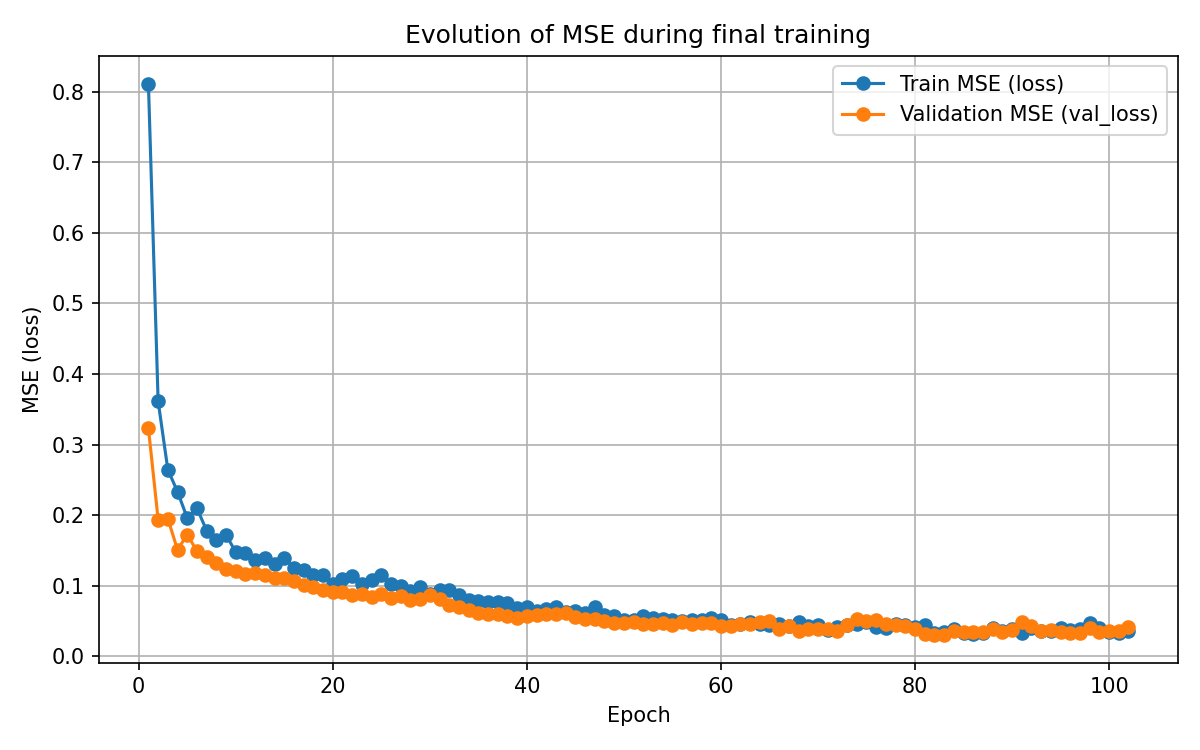

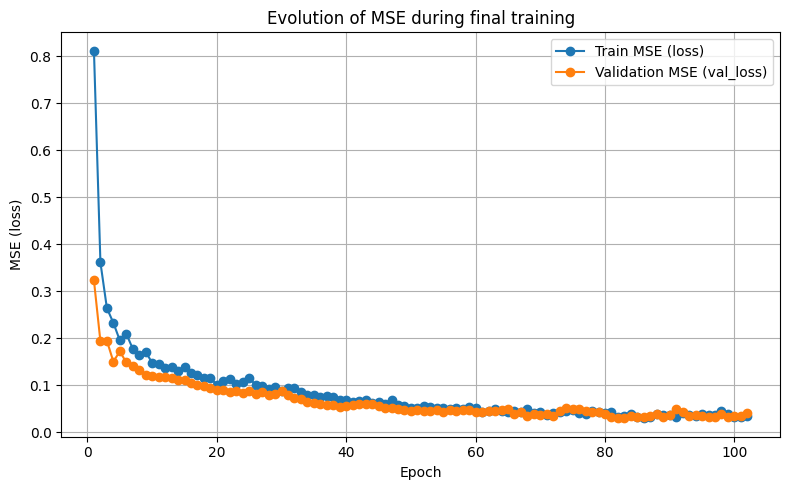

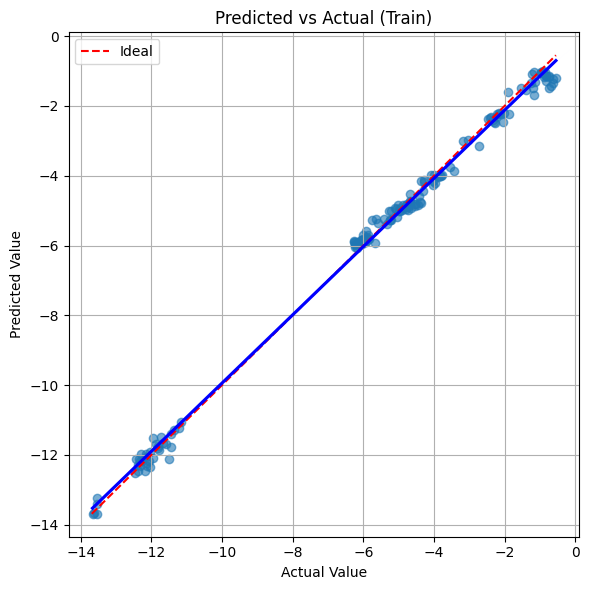

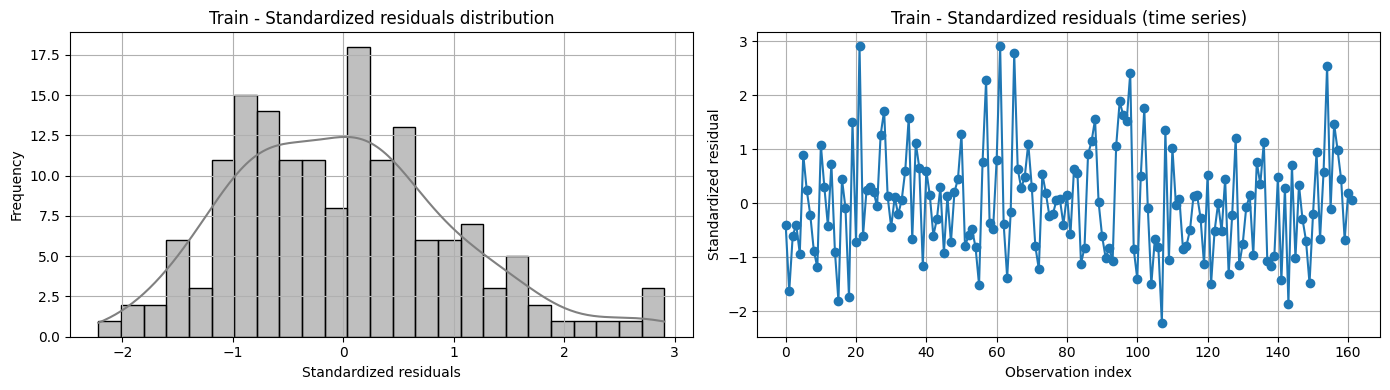

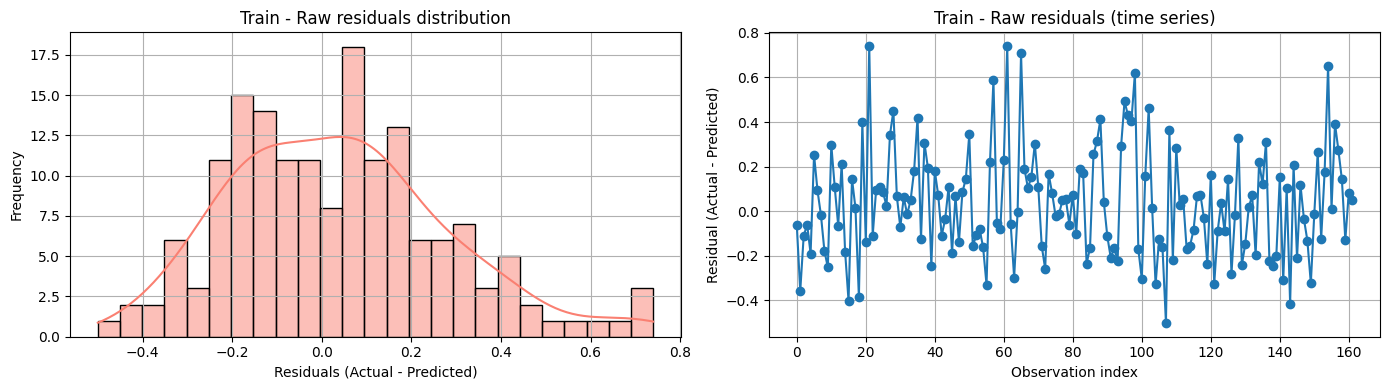

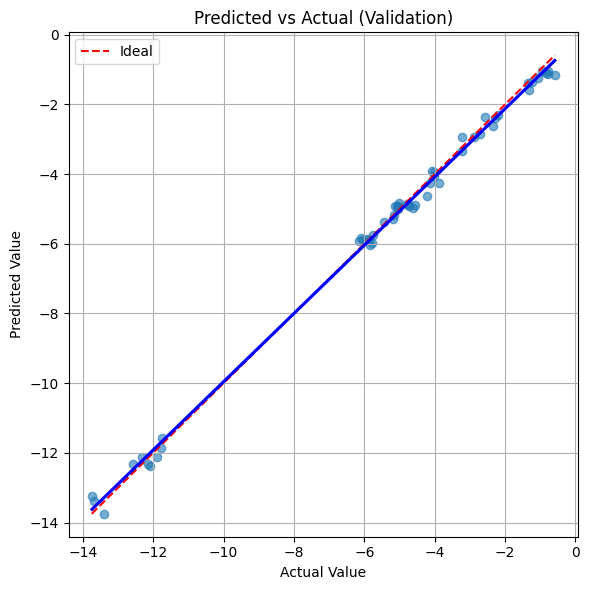

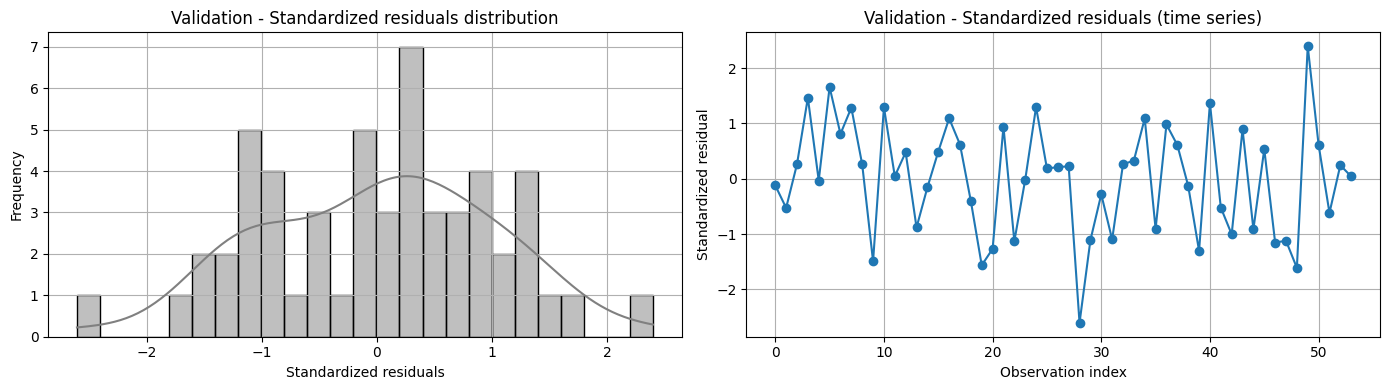

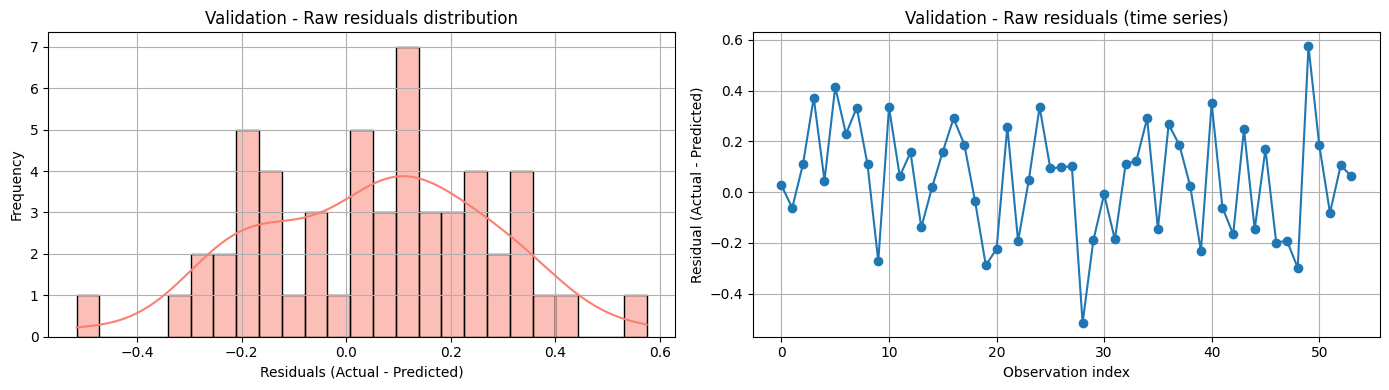

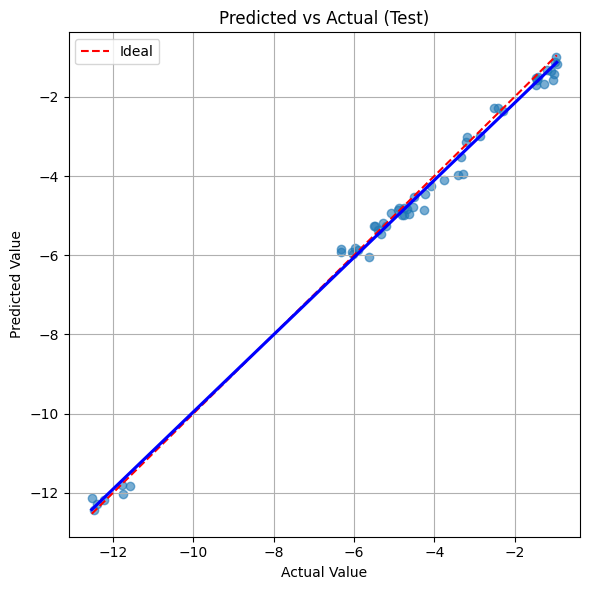

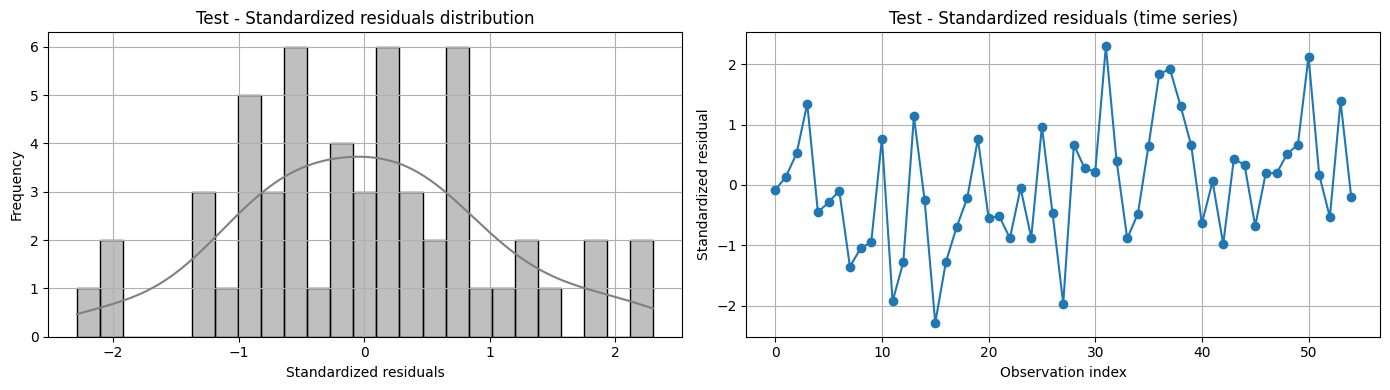

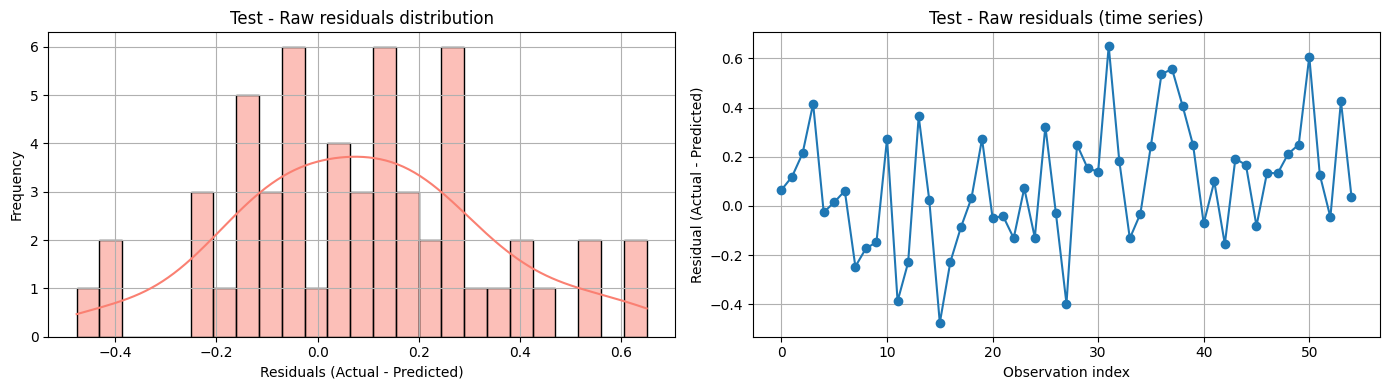

Diagnostic plots saved to: optimized_model/plots
Results exported to optimized_model/train_predictions.xlsx, optimized_model/val_predictions.xlsx, optimized_model/test_predictions.xlsx and CSV equivalents
Full-row exports saved


,File,WiscSIMS,δ18O true,18O/16O true,δ18O raw,18O/16O raw,IMF,IP,X,Y,...,16O1H/16O,MgCO3,CaCO3,MnCO3,FeCO3,Actual_Value,Predicted_Value,Residual,Abs_Error,Abs_Percent_Error
0,20140418@1001.asc,UWAnk3,15.82,0.002037,13.395,0.002032,0.997613,1.201456,-3003.0,-1671.0,...,0.001619,21.50,51.90,1.40,25.20,-2.387234,-2.324235,-0.062999,0.062999,2.639005
1,20141201@201.asc,UWAnk8,9.19,0.002024,2.872,0.002011,0.993740,1.300732,1021.0,-4213.0,...,0.000508,38.80,52.00,1.20,8.00,-6.260466,-5.902331,-0.358135,0.358135,5.720587
2,20141201@150.asc,UWAnk11,10.49,0.002026,-0.794,0.002004,0.988833,1.328738,3441.0,-503.0,...,0.002314,47.62,50.51,0.25,1.54,-11.166860,-11.057471,-0.109388,0.109388,0.979580
3,20141201@274.asc,UWAnk7,11.38,0.002028,5.435,0.002016,0.994122,1.254144,2933.0,2729.0,...,0.000424,39.60,51.60,0.20,8.60,-5.878107,-5.817393,-0.060714,0.060714,1.032881
4,20141201@226.asc,UWAnk9,11.68,0.002029,6.196,0.002018,0.994579,1.288488,-2790.0,-1006.0,...,0.000610,33.90,52.00,0.50,13.60,-5.420686,-5.231319,-0.189367,0.189367,3.493413


,File,WiscSIMS,δ18O true,18O/16O true,δ18O raw,18O/16O raw,IMF,IP,X,Y,...,16O1H/16O,MgCO3,CaCO3,MnCO3,FeCO3,Actual_Value,Predicted_Value,Residual,Abs_Error,Abs_Percent_Error
0,20141201@187.asc,UWAnk8,9.19,0.002024,3.283,0.002012,0.994147,1.303313,179.0,-2684.0,...,0.000533,38.80,52.00,1.20,8.00,-5.853209,-5.879343,0.026134,0.026134,0.446491
1,20140822@105.asc,UWAnk4,9.22,0.002024,5.170,0.002016,0.995987,1.312114,-2689.0,450.0,...,0.001214,38.84,51.46,1.24,8.46,-4.013000,-3.950540,-0.062460,0.062460,1.556449
2,20141201@79.asc,UWAnk1,15.87,0.002037,12.586,0.002030,0.996767,1.337500,-236.0,-2865.0,...,0.000245,22.11,52.03,1.72,24.10,-3.232697,-3.342549,0.109852,0.109852,3.398138
3,20140513@33.asc,UWAnk4,9.22,0.002024,5.305,0.002016,0.996121,1.170241,-956.0,-1941.0,...,0.001746,38.84,51.46,1.24,8.46,-3.879233,-4.250922,0.371689,0.371689,9.581500
4,20120710@49.asc,UWAnk2,15.90,0.002037,11.026,0.002027,0.995202,0.780775,-2849.0,-2582.0,...,0.000678,22.11,52.40,1.60,23.90,-4.797716,-4.843179,0.045462,0.045462,0.947585


,File,WiscSIMS,δ18O true,18O/16O true,δ18O raw,18O/16O raw,IMF,IP,X,Y,...,16O1H/16O,MgCO3,CaCO3,MnCO3,FeCO3,Actual_Value,Predicted_Value,Residual,Abs_Error,Abs_Percent_Error
0,20120710@67.asc,UWAnk2,15.90,0.002037,11.079,0.002027,0.995254,0.806929,2623.0,-3705.0,...,0.000659,22.11,52.40,1.60,23.90,-4.745546,-4.810472,0.064926,0.064926,1.368140
1,20140822@198.asc,UWAnk6a,15.99,0.002037,14.521,0.002034,0.998554,1.274720,3623.0,-972.0,...,0.001200,9.66,51.64,2.61,36.09,-1.445880,-1.564590,0.118710,0.118710,8.210204
2,20140822@117.asc,UWAnk4,9.22,0.002024,4.937,0.002015,0.995756,1.319703,4294.0,607.0,...,0.001320,38.84,51.46,1.24,8.46,-4.243872,-4.457549,0.213677,0.213677,5.034957
3,20140822@213.asc,UWAnk6a,15.99,0.002037,14.958,0.002035,0.998984,1.255279,2536.0,-4730.0,...,0.001333,9.66,51.64,2.61,36.09,-1.015758,-1.431214,0.415456,0.415456,40.901121
4,20141201@192.asc,UWAnk8,9.19,0.002024,3.236,0.002012,0.994100,1.292126,-2098.0,-2541.0,...,0.000534,38.80,52.00,1.20,8.00,-5.899781,-5.873638,-0.026143,0.026143,0.443124



MODEL TRAINING COMPLETED!
Training results are ready for download.


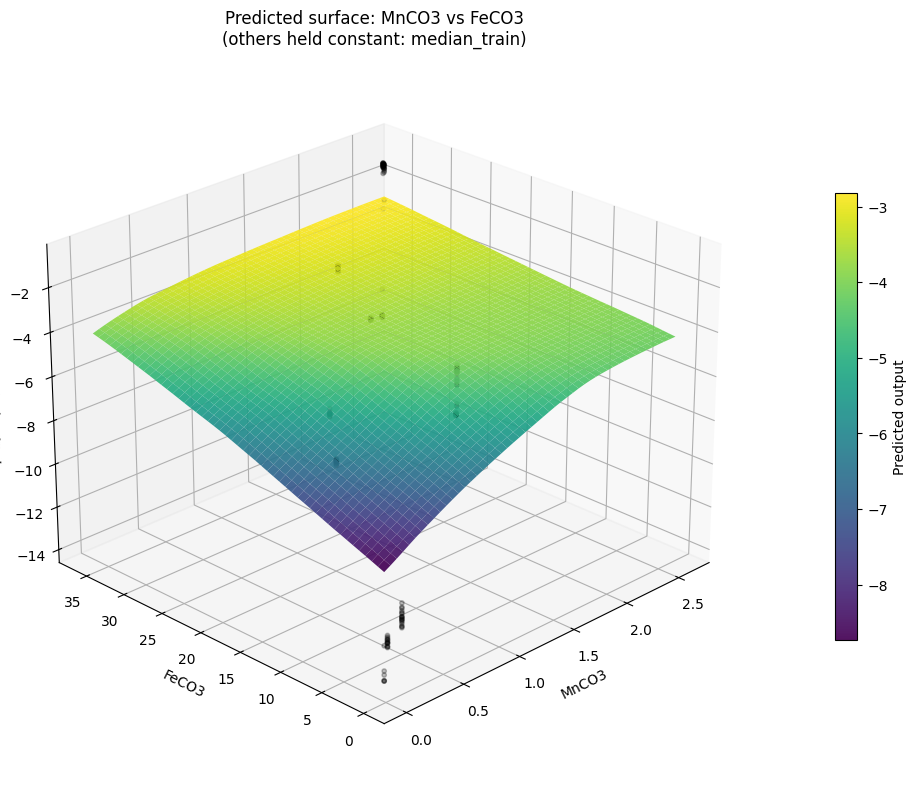

Plotting 12 3D surfaces; HOLD_MODE=median_train, GRID_N=35, RANGE=train_quantile


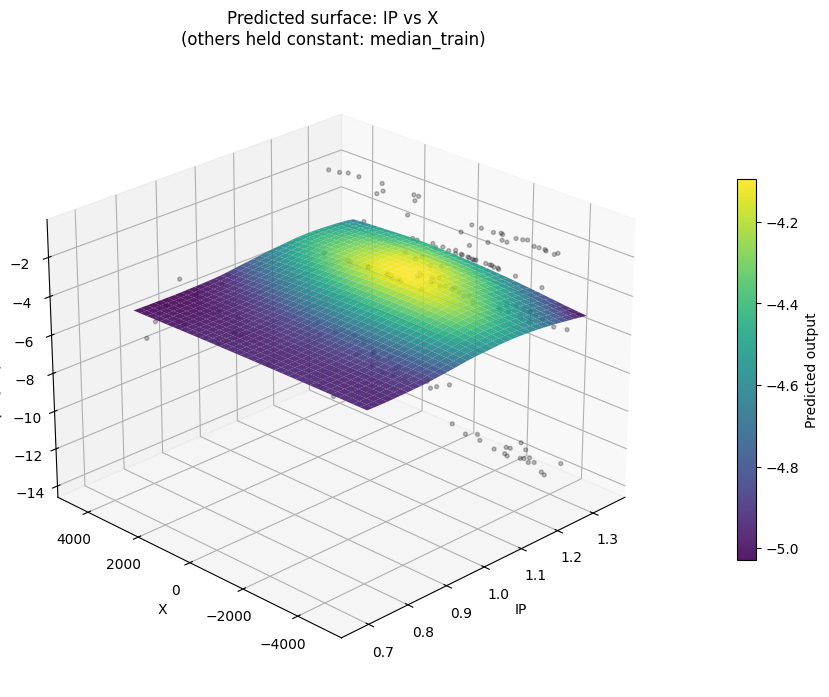

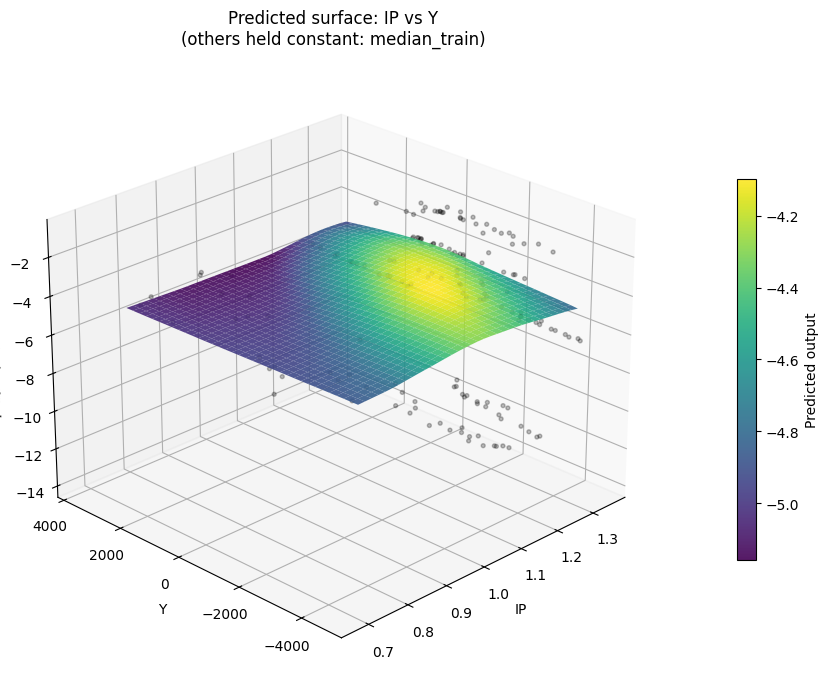

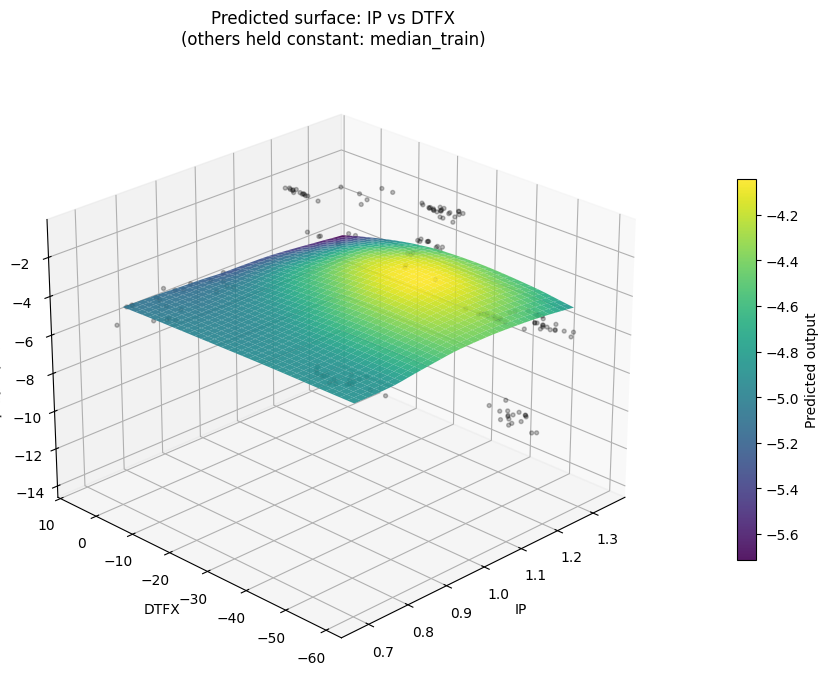

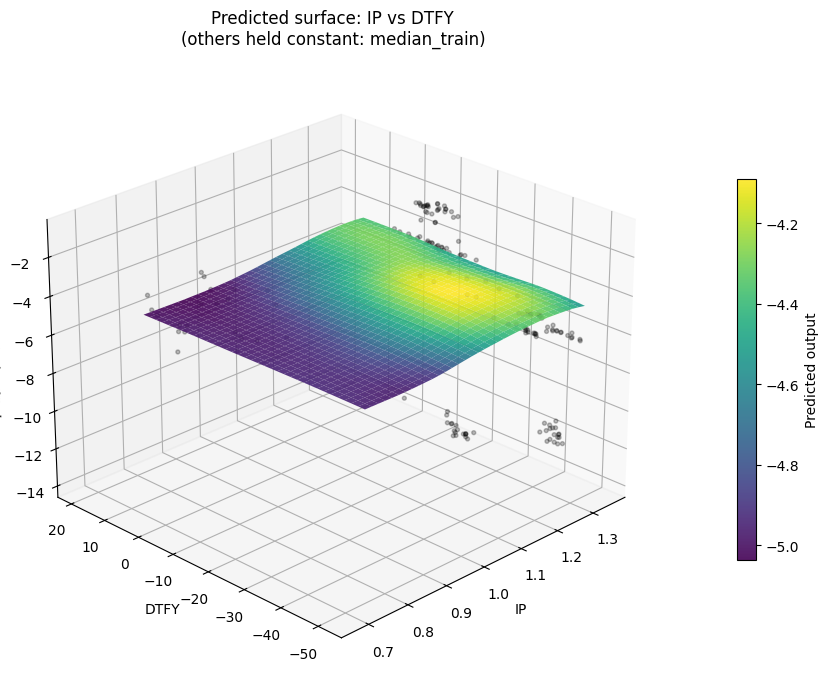

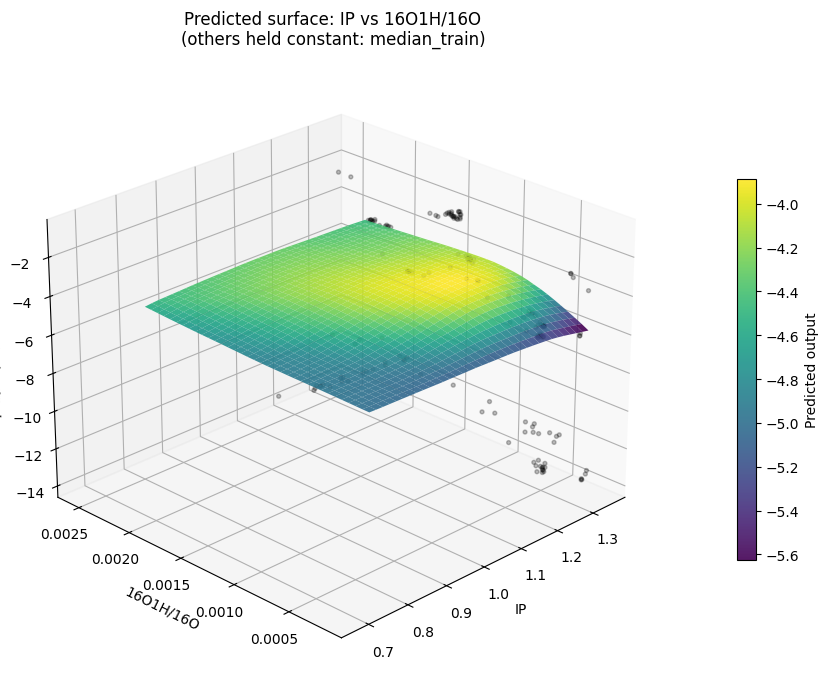

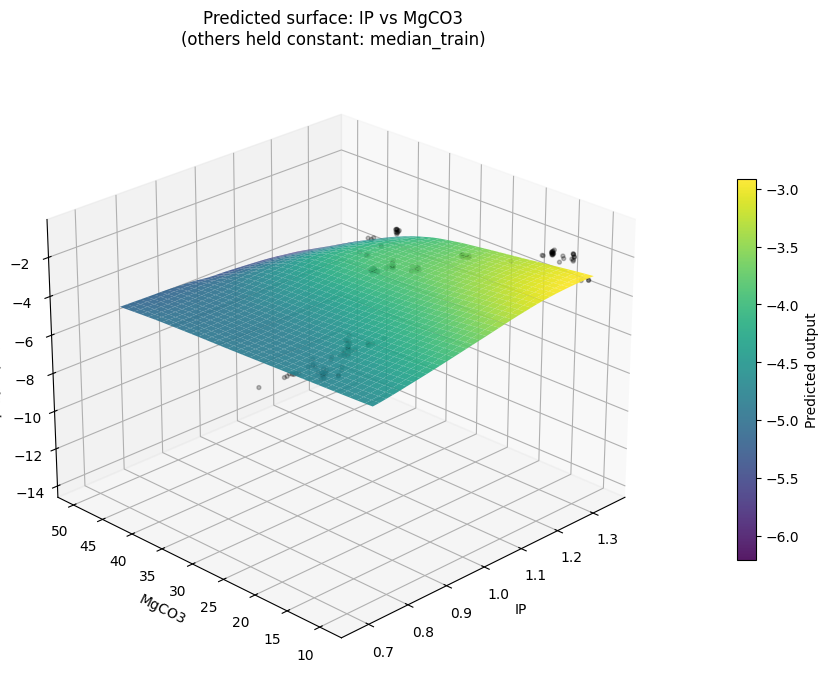

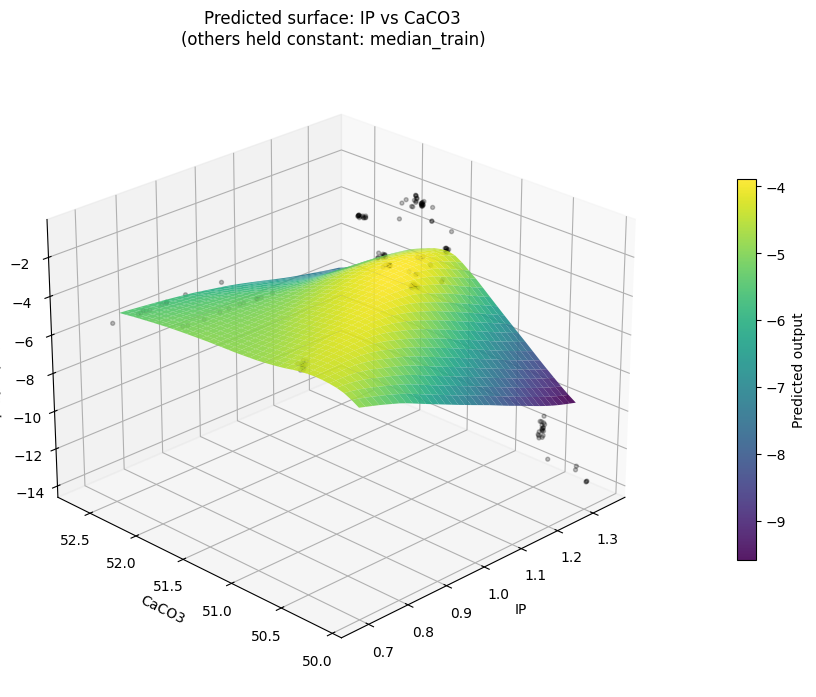

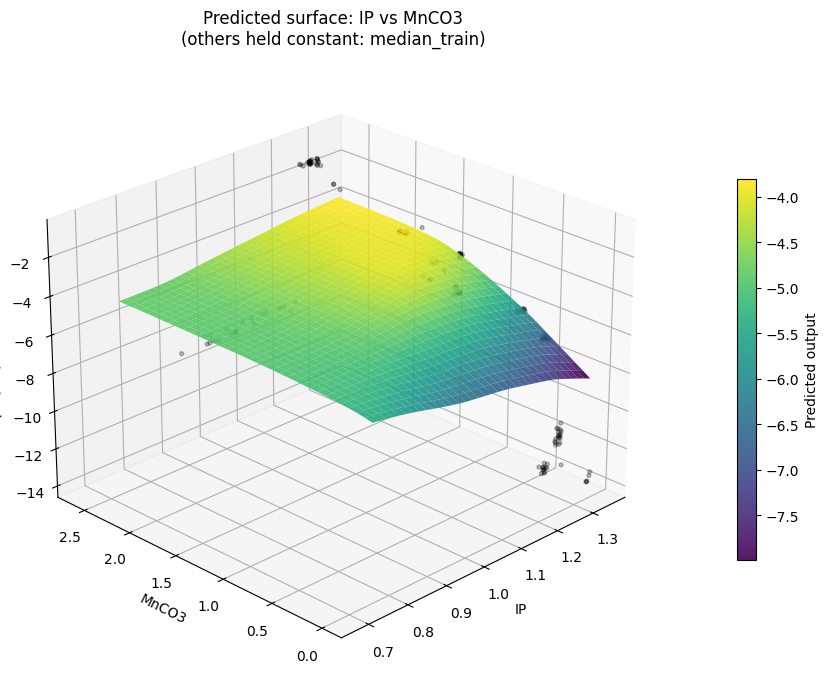

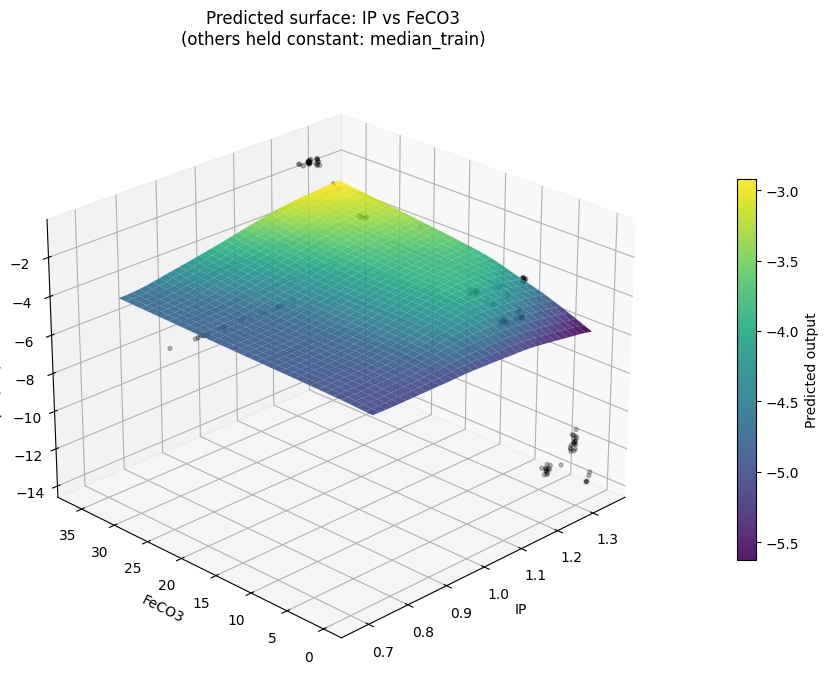

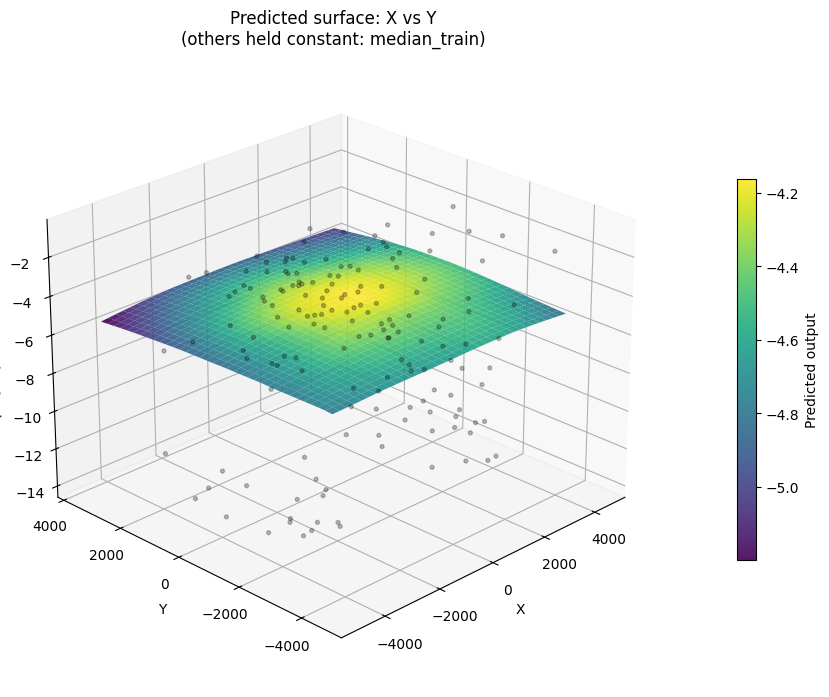

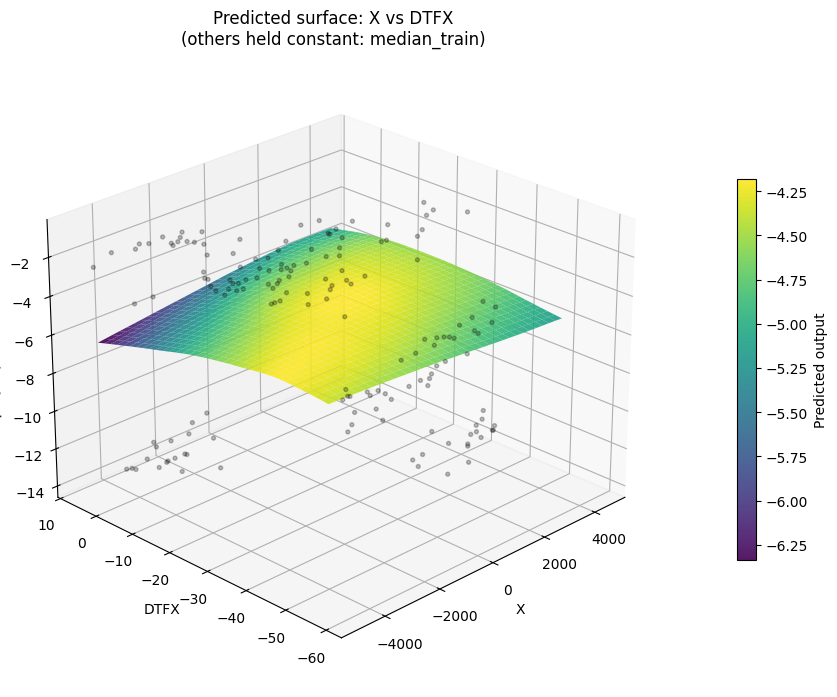

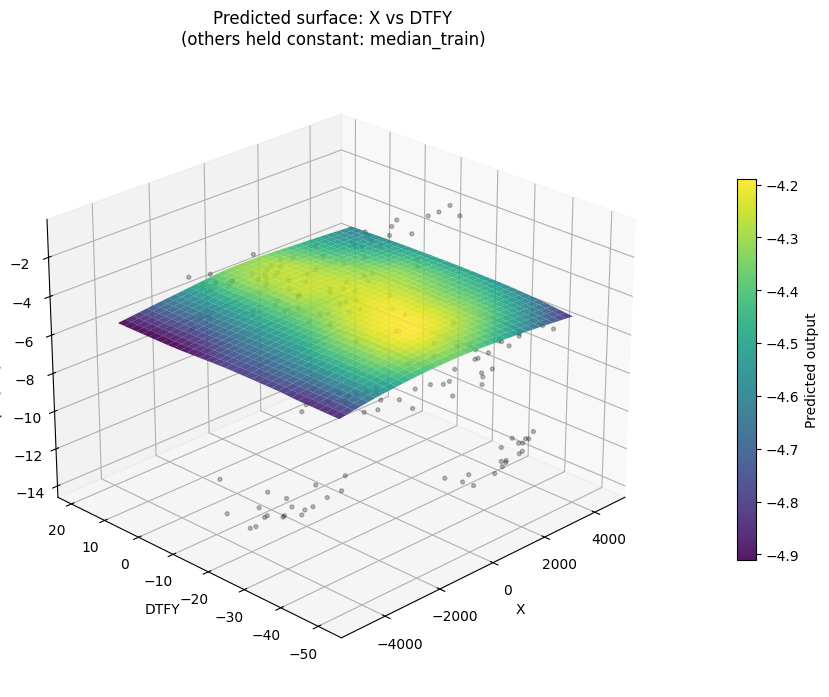


Generating 45 3D surfaces into: optimized_model/plots_3d
3D surfaces saved. Count: 45

DOWNLOAD #1: TRAINING RESULTS
--------------------------------------------------------------------------------
Creating ZIP archive of training files...
Found 73 training files
Created ZIP: training_results.zip (16.65 MB)

File location in Colab:
  1. Click the 'Files' folder icon on the left sidebar
  2. Look for 'training_results.zip'
  3. Right-click it and select 'Download'

Or run:
  from google.colab import files
  files.download('training_results.zip')

Download #1 Ready!


🔮 NEW DATA PREDICTION SECTION
Empirical PI calibration (val): q_low=-0.2956, q_high=0.4001 (alpha=0.05)

📂 Upload new data for predictions (optional).


In [ ]:
# Colab cell: Optimized ANN regression with configurable train/val/test split
# STRICT NO-LEAKAGE evaluation:
# - Split train/val/test
# - Tuner on train, validate on val
# - CV inside train with fold-fitted scalers (no leakage)
# - Final training on train, validate on val (early stop), then evaluate once on test
# - Optional retrain on train+val for best_epoch (val-chosen), with scalers refit on train+val, then evaluate once on test
#
# FIXES INCORPORATED:
# 1) "Clean" optional retrain: refit X/y scalers on train+val before retraining + test eval
# 2) Better uncertainty bands: calibrated using VAL residuals (or OOF residuals from CV), producing empirical quantile interval
#
# PATCH FIXES (2026-02-24):
# - Fixed typo: reshape(--1) -> reshape(-1)
# - Fixed date written to stats file (now uses current date dynamically)
# - Safer metric evaluation: flatten arrays before sklearn metrics
#
# INCLUDES TWO DOWNLOAD SECTIONS:
# 1. After model training - downloads train/val/test results
# 2. After new data predictions - downloads new data predictions
#
# Paste this entire cell into Colab and run. Adjust USER CONFIG as needed.

# --- Detect notebook / Colab ---
try:
    get_ipython  # type: ignore
    IN_NOTEBOOK = True
except Exception:
    IN_NOTEBOOK = False

# --- Install dependencies (if running in notebook) ---
if IN_NOTEBOOK:
    print("Installing (if missing) keras-tuner, seaborn, openpyxl, joblib...")
    %pip install -q "keras-tuner" seaborn openpyxl joblib
else:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "keras-tuner", "seaborn", "openpyxl", "joblib"])

# --- Imports ---
import os
import shutil
import traceback
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as _dt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# Keras tuner import with fallback
try:
    import keras_tuner as kt
except Exception:
    try:
        import kerastuner as kt
    except Exception:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "keras-tuner"])
        import importlib as _importlib
        _importlib.invalidate_caches()
        import keras_tuner as kt

# Colab files helper
use_colab = False
try:
    from google.colab import files as colab_files  # type: ignore
    use_colab = True
except Exception:
    use_colab = False

# Safe display helper
def _show(obj, n=5):
    if IN_NOTEBOOK:
        try:
            display(obj)  # type: ignore
        except Exception:
            print(obj)
    else:
        try:
            print(obj.head(n))
        except Exception:
            print(obj)

# ----------------- USER CONFIGURATION -----------------
TRAIN_PERCENT = 60
VAL_PERCENT = 20
TEST_PERCENT = 20

N_LABELS = 7
N_INPUTS = 10
TARGET_COL = None          # If not None: absolute column index of target in df
SEP = "\t"

DISABLE_GPU = True

TUNER_TRIALS = 15
K_FOLDS = 15
RANDOM_SEED = 42
TUNER_EPOCHS = 200
CV_EPOCHS = 200
FINAL_EPOCHS = 200

# Advanced fine-tuning config
FT_EPOCHS_S1 = 40    # head only
FT_EPOCHS_S2 = 60    # last hidden + head
FT_EPOCHS_S3 = 100   # full unfreeze (total = 200)
FT_LR_S1 = 8e-4
FT_LR_S2 = 3e-4
FT_LR_S3 = 8e-5
FT_CLIPNORM = 1.0
FT_USE_EMA = True
FT_EMA_MOMENTUM = 0.99
FT_WEIGHT_DECAY = 1e-5
FT_USE_HUBER = True
FT_HUBER_DELTA = 1.0

DO_OPTIONAL_RETRAIN = True  # retrain on train+val for val-selected best_epoch (with scalers refit on train+val)
PI_CALIBRATION = "val"      # "val" or "oof" for empirical prediction interval calibration
PI_ALPHA = 0.05             # 95% PI => alpha=0.05 (2.5%/97.5% quantiles)

EXPORT_DIR = "optimized_model"
# ------------------------------------------------------

total_percent = TRAIN_PERCENT + VAL_PERCENT + TEST_PERCENT
if abs(total_percent - 100) > 0.01:
    raise ValueError(f"Split percentages must sum to 100. Got: {TRAIN_PERCENT}% + {VAL_PERCENT}% + {TEST_PERCENT}% = {total_percent}%")

print(f"✓ Data split configuration: TRAIN={TRAIN_PERCENT}%, VAL={VAL_PERCENT}%, TEST={TEST_PERCENT}%")

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

if DISABLE_GPU:
    try:
        tf.config.set_visible_devices([], 'GPU')
        print("GPU disabled (if present). Using CPU.")
    except Exception as e:
        print("Could not change GPU visibility:", e)

# --- Robust table loader (Excel + common text encodings + separator sniff) ---
def load_table(path, sep=SEP):
    _, ext = os.path.splitext(path.lower())

    if ext in [".xlsx", ".xls", ".xlsm"]:
        print(f"Detected Excel file: {path}")
        return pd.read_excel(path, engine="openpyxl")

    encodings_to_try = ["utf-8", "utf-8-sig", "cp1252", "latin1"]
    last_err = None
    for enc in encodings_to_try:
        try:
            print(f"Trying read_csv: sep={repr(sep)} encoding={enc}")
            return pd.read_csv(path, sep=sep, encoding=enc)
        except UnicodeDecodeError as e:
            last_err = e
        except Exception as e:
            last_err = e

    for enc in encodings_to_try:
        try:
            print(f"Fallback sniff: sep=None encoding={enc} (python engine)")
            return pd.read_csv(path, sep=None, engine="python", encoding=enc)
        except Exception as e:
            last_err = e

    raise RuntimeError(f"Failed to read '{path}'. Last error: {last_err}")

# --- Upload / load data ---
print("📂 Upload your dataset (dialog appears if running in Colab).")
if use_colab:
    uploaded = colab_files.upload()
    if len(uploaded) == 0:
        raise RuntimeError("No file uploaded.")
    file_name = list(uploaded.keys())[0]
else:
    file_name = "data.tsv"
    if not os.path.exists(file_name):
        raise FileNotFoundError("Not in Colab and 'data.tsv' not found. Upload or change the path.")

df = load_table(file_name, sep=SEP)

print(f"✅ Data loaded. Shape: {df.shape}")
_show(df.head())

# --- Column selection (flexible) ---
n_cols = df.shape[1]
if TARGET_COL is not None:
    target_idx = TARGET_COL
    if target_idx < 0 or target_idx >= n_cols:
        raise IndexError("TARGET_COL out of range.")
    labels_df = df.iloc[:, :N_LABELS] if N_LABELS > 0 else pd.DataFrame()
    input_cols = list(range(N_LABELS, n_cols))
    input_cols.remove(target_idx)
    inputs_df = df.iloc[:, input_cols]
    y_full = df.iloc[:, target_idx].values.reshape(-1, 1)
else:
    if N_LABELS + N_INPUTS >= n_cols:
        print("N_LABELS + N_INPUTS >= total columns. Using last column as target and the middle columns as inputs.")
        labels_df = df.iloc[:, :N_LABELS] if N_LABELS > 0 else pd.DataFrame()
        inputs_df = df.iloc[:, N_LABELS:-1]
        y_full = df.iloc[:, -1].values.reshape(-1, 1)
    else:
        labels_df = df.iloc[:, :N_LABELS] if N_LABELS > 0 else pd.DataFrame()
        inputs_df = df.iloc[:, N_LABELS:N_LABELS + N_INPUTS]
        y_full = df.iloc[:, N_LABELS + N_INPUTS].values.reshape(-1, 1)

print(f"Labels shape: {labels_df.shape}, Inputs shape: {inputs_df.shape}, y shape: {y_full.shape}")

X_full = inputs_df.values
y_full_arr = y_full
labels_full = labels_df
row_pos = np.arange(len(df))

# ============ CONFIGURABLE SPLIT ============
test_frac = TEST_PERCENT / 100.0
val_frac = VAL_PERCENT / 100.0
train_frac = TRAIN_PERCENT / 100.0

X_temp, X_test_orig, y_temp, y_test_orig, labels_temp, labels_test, idx_temp, idx_test = train_test_split(
    X_full, y_full_arr, labels_full, row_pos, test_size=test_frac, random_state=RANDOM_SEED
)
val_split_ratio = val_frac / (train_frac + val_frac)
X_train_orig, X_val_orig, y_train_orig, y_val_orig, labels_train, labels_val, idx_train, idx_val = train_test_split(
    X_temp, y_temp, labels_temp, idx_temp, test_size=val_split_ratio, random_state=RANDOM_SEED
)

inputs_columns = list(inputs_df.columns)
X_train_df = pd.DataFrame(X_train_orig, columns=inputs_columns).reset_index(drop=True)
X_val_df   = pd.DataFrame(X_val_orig,   columns=inputs_columns).reset_index(drop=True)
X_test_df  = pd.DataFrame(X_test_orig,  columns=inputs_columns).reset_index(drop=True)

print(f"\nSplit sizes (rows): train={len(X_train_orig)} val={len(X_val_orig)} test={len(X_test_orig)}")
print(f"Split percentages: train={100*len(X_train_orig)/len(df):.1f}% val={100*len(X_val_orig)/len(df):.1f}% test={100*len(X_test_orig)/len(df):.1f}%")

# --- Scaling for tuning + final training (fit only on TRAIN to avoid leakage) ---
scaler_X = StandardScaler().fit(X_train_orig)
scaler_y = StandardScaler().fit(y_train_orig)

X_train = scaler_X.transform(X_train_orig)
X_val   = scaler_X.transform(X_val_orig)
X_test  = scaler_X.transform(X_test_orig)

y_train = scaler_y.transform(y_train_orig)
y_val   = scaler_y.transform(y_val_orig)
y_test  = scaler_y.transform(y_test_orig)

# --- Model builder for Keras-Tuner ---
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))
    n_layers = hp.Int('num_layers', 2, 6, step=1)

    # l2 shared across layers (as in your original); kept for comparability
    l2_val = hp.Choice('l2_reg', [1e-4, 1e-3, 1e-2])

    for i in range(n_layers):
        units = hp.Int(f'units_{i}', 64, 512, step=64)
        model.add(layers.Dense(
            units,
            activation='relu',
            kernel_regularizer=regularizers.l2(l2_val)
        ))
        model.add(layers.Dropout(hp.Float(f'dropout_{i}', 0.0, 0.5, step=0.1)))

    model.add(layers.Dense(1, activation='linear'))
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('lr', [1e-4, 5e-4, 1e-3, 5e-3])
        ),
        loss='mse',
        metrics=['mae']
    )
    return model

# --- Keras-Tuner search (RandomSearch) ---
tuner = kt.RandomSearch(
    build_model_fixed,  # ← THIS
    objective='val_loss',
    max_trials=TUNER_TRIALS,
    executions_per_trial=1,
    directory='tuner_results',
    project_name=f'ann_{TRAIN_PERCENT}_{VAL_PERCENT}_{TEST_PERCENT}'
)

print(f"Starting hyperparameter search ({TUNER_TRIALS} trials). This may take a while.")
tuner.search(X_train, y_train, validation_data=(X_val, y_val), epochs=TUNER_EPOCHS, batch_size=32, verbose=1)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters found:")
for k, v in best_hp.values.items():
    print(f"  {k}: {v}")

# ---- Weight transfer from warmup_model (if available) ----
print("\n" + "="*70)
print("WEIGHT TRANSFER: Checking for pre-trained Hill model...")
print("="*70)

_model_with_pretrain = None

if 'warmup_model' in globals():
    print("✓ Found pre-trained warmup_model!")
    try:
        model_for_transfer = tuner.hypermodel.build(best_hp)

        n_transferred = 0
        for layer_final, layer_warmup in zip(model_for_transfer.layers, warmup_model.layers):
            # Skip Input layers
            if isinstance(layer_final, layers.InputLayer) or isinstance(layer_warmup, layers.InputLayer):
                continue

            if not layer_final.weights or not layer_warmup.weights:
                continue

            try:
                if layer_final.name.split('_')[0] == layer_warmup.name.split('_')[0]:  # Same layer type
                    layer_final.set_weights(layer_warmup.get_weights())  # Use set_weights instead
                    n_transferred += 1
                    print(f"  ✓ {layer_warmup.name} → {layer_final.name}")
            except Exception as e:
                print(f"  ⚠️ Skipping {layer_warmup.name}: {e}")

        if n_transferred > 0:
            print(f"✓ Transferred {n_transferred} layers!")
            _model_with_pretrain = model_for_transfer
        else:
            print("⚠️ No compatible weights (architecture mismatch)")
    except Exception as e:
        print(f"✗ Weight transfer failed: {e}")
else:
    print("ℹ️  No pre-trained model found")

print("="*70 + "\n")

# ======================================================
# STRICT NO-LEAKAGE CV inside TRAIN with fold-fitted scalers
# ======================================================
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)

r2_scores, rmse_scores, mae_scores = [], [], []
y_oof_pred_inv = np.full(shape=(len(y_train_orig),), fill_value=np.nan, dtype=float)
y_oof_true_inv = np.full(shape=(len(y_train_orig),), fill_value=np.nan, dtype=float)

print(f"\nRunning {K_FOLDS}-Fold CV on TRAIN split ONLY with fold-fitted scalers (no leakage)...")

# Check for pre-trained model once (before loop)
if '_model_with_pretrain' in globals() and _model_with_pretrain is not None:
    print("✓ Using pre-trained model from Cell B")
    base_model = _model_with_pretrain
    use_pretrain = True
else:
    print("⚠️  Pre-trained model not found, building fresh model...")
    use_pretrain = False

print(f"✓ Model ready for k-fold CV\n")

# ← START OF FOR LOOP (all code below is indented inside the loop)
for fold, (tr_idx, va_idx) in enumerate(kf.split(X_train_orig), start=1):
    X_tr_orig, X_va_orig = X_train_orig[tr_idx], X_train_orig[va_idx]
    y_tr_orig, y_va_orig = y_train_orig[tr_idx], y_train_orig[va_idx]

    fold_scaler_X = StandardScaler().fit(X_tr_orig)
    fold_scaler_y = StandardScaler().fit(y_tr_orig)

    X_tr = fold_scaler_X.transform(X_tr_orig)
    X_va = fold_scaler_X.transform(X_va_orig)
    y_tr = fold_scaler_y.transform(y_tr_orig)
    y_va = fold_scaler_y.transform(y_va_orig)

    # Build model for this fold
    model_fold = build_model_fixed(best_hp)

    # If using pre-trained weights, load them
    if use_pretrain:
        model_fold.set_weights(base_model.get_weights())



    # Train on this fold
    es = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

    model_fold.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=TUNER_EPOCHS,
        batch_size=32,
        callbacks=[es],
        verbose=1
    )

    # Predict on validation fold
    y_va_pred_scaled = model_fold.predict(X_va, verbose=0)
    y_va_pred_inv = fold_scaler_y.inverse_transform(y_va_pred_scaled).reshape(-1)
    y_va_true_inv = y_va_orig.reshape(-1)

    y_oof_pred_inv[va_idx] = y_va_pred_inv
    y_oof_true_inv[va_idx] = y_va_true_inv

    r2 = r2_score(y_va_true_inv, y_va_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_va_true_inv, y_va_pred_inv))
    mae = np.mean(np.abs(y_va_true_inv - y_va_pred_inv))

    r2_scores.append(r2)
    rmse_scores.append(rmse)
    mae_scores.append(mae)

    print(f"Fold {fold}: R²={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}")

# ← END OF FOR LOOP (code below is no longer indented)

print("\nCV Metrics (Mean ± Std) on TRAIN split (no leakage):")
print(f"R²:   {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"RMSE: {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"MAE:  {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")

if np.isnan(y_oof_pred_inv).any():
    raise RuntimeError("OOF predictions contain NaNs. Check fold logic.")

ss_res_press = np.sum((y_oof_true_inv - y_oof_pred_inv) ** 2)
ss_tot_train = np.sum((y_oof_true_inv - np.mean(y_oof_true_inv)) ** 2)
pred_R2_train = 1.0 - ss_res_press / ss_tot_train if ss_tot_train != 0 else np.nan
print(f"\nPredicted R² (Q²) on TRAIN split (OOF/PRESS, no leakage): {pred_R2_train:.4f}")

# ======================================================
# Final training with ADVANCED FINE-TUNING
# TRAIN -> validate on VAL (no test leakage)
# 3-stage progressive unfreezing: head -> last hidden + head -> full
# ======================================================
print("\n" + "="*70)
print("FINAL TRAINING WITH ADVANCED FINE-TUNING")
print("="*70)

os.makedirs(EXPORT_DIR, exist_ok=True)
checkpoint_path = os.path.join(EXPORT_DIR, "best_model.keras")

tf.keras.backend.clear_session()
model = tuner.hypermodel.build(best_hp)

# Transfer pre-trained weights if available
if '_model_with_pretrain' in globals() and _model_with_pretrain is not None:
    try:
        n_ft_transferred = 0
        for layer_final, layer_pre in zip(model.layers, _model_with_pretrain.layers):
            if isinstance(layer_final, layers.InputLayer) or isinstance(layer_pre, layers.InputLayer):
                continue
            if not layer_final.weights or not layer_pre.weights:
                continue
            try:
                w_pre = layer_pre.get_weights()
                w_fin = layer_final.get_weights()
                if len(w_pre) == len(w_fin) and all(a.shape == b.shape for a, b in zip(w_pre, w_fin)):
                    layer_final.set_weights(w_pre)
                    n_ft_transferred += 1
            except Exception:
                pass
        print(f"Transferred {n_ft_transferred} layer(s) from pre-trained model.")
    except Exception as e:
        print(f"Weight transfer failed: {e}")
else:
    print("No pre-trained model found; training from tuned initialization.")

# --- Fine-tuning helpers ---
def _ft_make_optimizer(lr):
    return keras.optimizers.AdamW(
        learning_rate=lr,
        weight_decay=FT_WEIGHT_DECAY,
        clipnorm=FT_CLIPNORM,
        use_ema=FT_USE_EMA,
        ema_momentum=FT_EMA_MOMENTUM
    )

def _ft_make_loss():
    return keras.losses.Huber(delta=FT_HUBER_DELTA) if FT_USE_HUBER else "mse"

def _ft_compile(mdl, lr):
    mdl.compile(
        optimizer=_ft_make_optimizer(lr),
        loss=_ft_make_loss(),
        metrics=[
            keras.metrics.MeanAbsoluteError(name='mae'),
            keras.metrics.RootMeanSquaredError(name='rmse')
        ]
    )

def _ft_stage_callbacks(stage_name, es_patience=15, rlr_patience=5, min_lr=1e-7):
    return [
        callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        ),
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=es_patience,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=rlr_patience,
            min_lr=min_lr,
            verbose=1
        ),
        callbacks.TerminateOnNaN(),
        callbacks.CSVLogger(os.path.join(EXPORT_DIR, f"finetune_{stage_name}.csv"), append=False),
    ]

dense_layers_ft = [l for l in model.layers if isinstance(l, layers.Dense)]
print(f"Dense layers for fine-tuning: {[l.name for l in dense_layers_ft]}")

# ---- Stage S1: Head only (output layer) ----
print(f"\n[S1] Train output head only ({FT_EPOCHS_S1} epochs, lr={FT_LR_S1})")
for l in model.layers:
    l.trainable = True
for l in dense_layers_ft[:-1]:
    l.trainable = False
dense_layers_ft[-1].trainable = True

_ft_compile(model, FT_LR_S1)
hist_s1 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=FT_EPOCHS_S1,
    batch_size=32,
    callbacks=_ft_stage_callbacks("s1", es_patience=12, rlr_patience=4),
    verbose=1
)
best_s1 = np.min(hist_s1.history["val_loss"])
print(f"S1 best val_loss: {best_s1:.6f}")

# ---- Stage S2: Last hidden + head ----
print(f"\n[S2] Unfreeze last hidden + head ({FT_EPOCHS_S2} epochs, lr={FT_LR_S2})")
for l in model.layers:
    if isinstance(l, layers.Dense):
        l.trainable = False
if len(dense_layers_ft) >= 2:
    dense_layers_ft[-2].trainable = True
dense_layers_ft[-1].trainable = True

_ft_compile(model, FT_LR_S2)
hist_s2 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=FT_EPOCHS_S2,
    batch_size=32,
    callbacks=_ft_stage_callbacks("s2", es_patience=15, rlr_patience=5),
    verbose=1
)
best_s2 = np.min(hist_s2.history["val_loss"])
print(f"S2 best val_loss: {best_s2:.6f}")

# ---- Stage S3: Full unfreeze ----
print(f"\n[S3] Full unfreeze ({FT_EPOCHS_S3} epochs, lr={FT_LR_S3})")
for l in model.layers:
    l.trainable = True

_ft_compile(model, FT_LR_S3)
hist_s3 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=FT_EPOCHS_S3,
    batch_size=32,
    callbacks=_ft_stage_callbacks("s3", es_patience=20, rlr_patience=6, min_lr=1e-8),
    verbose=1
)
best_s3 = np.min(hist_s3.history["val_loss"])
print(f"S3 best val_loss: {best_s3:.6f}")

best_overall = min(best_s1, best_s2, best_s3)
print(f"\nBest overall val_loss (all stages): {best_overall:.6f}")

# Reload global-best checkpoint across all stages
if os.path.exists(checkpoint_path):
    model = keras.models.load_model(checkpoint_path, compile=False)
    print(f"Reloaded global best checkpoint: {checkpoint_path}")
else:
    print("Checkpoint not found; using in-memory model.")

# Combine histories for plotting
history_combined = {"loss": [], "val_loss": []}
for h in [hist_s1, hist_s2, hist_s3]:
    history_combined["loss"].extend(h.history.get("loss", []))
    history_combined["val_loss"].extend(h.history.get("val_loss", []))

# Create a simple namespace so downstream code can use history.history
class _HistoryWrapper:
    def __init__(self, d):
        self.history = d
history = _HistoryWrapper(history_combined)

best_epoch = int(np.argmin(history_combined["val_loss"]) + 1)
print(f"Best epoch selected by VAL loss (across all stages): {best_epoch}")

# Evaluate ONCE on TEST (no tuning on test)
print("\nEvaluating once on TEST (no selection/tuning on test).")
y_test_pred_eval = scaler_y.inverse_transform(model.predict(X_test, verbose=0)).reshape(-1)
y_test_inv_eval  = scaler_y.inverse_transform(y_test).reshape(-1)
print(f"TEST: R\u00b2={r2_score(y_test_inv_eval, y_test_pred_eval):.4f}, "
      f"RMSE={np.sqrt(mean_squared_error(y_test_inv_eval, y_test_pred_eval)):.4f}, "
      f"MAE={np.mean(np.abs(y_test_inv_eval - y_test_pred_eval)):.4f}")

# ======================================================
# Optional retrain on TRAIN+VAL for best_epoch (VAL-informed),
# with scalers refit on TRAIN+VAL (clean retrain), then evaluate once on TEST.
# ======================================================
if DO_OPTIONAL_RETRAIN:
    print("\nOptional retrain (clean): refit scalers on TRAIN+VAL, retrain for best_epoch, evaluate once on TEST.")
    X_trainval_orig = np.vstack([X_train_orig, X_val_orig])
    y_trainval_orig = np.vstack([y_train_orig, y_val_orig])

    scaler_X_tv = StandardScaler().fit(X_trainval_orig)
    scaler_y_tv = StandardScaler().fit(y_trainval_orig)

    X_trainval_tv = scaler_X_tv.transform(X_trainval_orig)
    y_trainval_tv = scaler_y_tv.transform(y_trainval_orig)

    X_test_tv = scaler_X_tv.transform(X_test_orig)
    y_test_tv = scaler_y_tv.transform(y_test_orig)

    tf.keras.backend.clear_session()
    model_retrain = tuner.hypermodel.build(best_hp)
    model_retrain.fit(
        X_trainval_tv, y_trainval_tv,
        epochs=best_epoch,
        batch_size=32,
        verbose=1
    )

    y_test_pred_rt = scaler_y_tv.inverse_transform(model_retrain.predict(X_test_tv, verbose=0)).reshape(-1)
    y_test_inv_rt  = y_test_orig.reshape(-1)  # already inverse-space

    print(f"TEST (retrained): R²={r2_score(y_test_inv_rt, y_test_pred_rt):.4f}, "
          f"RMSE={np.sqrt(mean_squared_error(y_test_inv_rt, y_test_pred_rt)):.4f}, "
          f"MAE={np.mean(np.abs(y_test_inv_rt - y_test_pred_rt)):.4f}")

    # Use retrained artifacts for subsequent exports/predictions
    model = model_retrain
    scaler_X = scaler_X_tv
    scaler_y = scaler_y_tv
    X_train = scaler_X.transform(X_train_orig)
    X_val   = scaler_X.transform(X_val_orig)
    X_test  = scaler_X.transform(X_test_orig)
    y_train = scaler_y.transform(y_train_orig)
    y_val   = scaler_y.transform(y_val_orig)
    y_test  = scaler_y.transform(y_test_orig)
    print("Using retrained model + train+val-fitted scalers for exports/predictions.")

# --- Print & save final Dense architecture ---
try:
    from tensorflow.keras.layers import Dense
    dense_layers = [layer for layer in model.layers if isinstance(layer, Dense)]
    if dense_layers:
        print("\n=== Final Dense Layers (in model order) ===")
        scheme_lines = []
        for i, layer in enumerate(dense_layers, start=1):
            units = getattr(layer, "units", None)
            activation = getattr(layer, "activation", None)
            act_name = activation.__name__ if activation is not None else "N/A"
            reg = getattr(layer, "kernel_regularizer", None)
            reg_str = None
            try:
                if reg is not None and hasattr(reg, "l2"):
                    reg_str = f"L2={getattr(reg,'l2')}"
                elif reg is not None:
                    reg_str = str(reg)
            except Exception:
                reg_str = str(reg)
            line = f"Layer {i}: name='{layer.name}', units={units}, activation={act_name}"
            if reg_str:
                line += f", regularizer={reg_str}"
            print(line)
            scheme_lines.append(line)
        last = dense_layers[-1]
        final_line = f"Final Dense (output) -> name='{last.name}', units={getattr(last,'units',None)}, activation={getattr(last,'activation').__name__ if getattr(last,'activation',None) else 'N/A'}"
        print("\n" + final_line)
        scheme_lines.append("")
        scheme_lines.append(final_line)
        scheme_path = os.path.join(EXPORT_DIR, "model_scheme.txt")
        with open(scheme_path, "w", encoding="utf-8") as f:
            f.write("Final Dense Layers (in model order)\n")
            f.write("===============================\n")
            for ln in scheme_lines:
                f.write(ln + "\n")
        print(f"Model scheme saved to: {scheme_path}")
except Exception as e:
    print("Error while printing/saving model architecture:", e)

# --- Save model & scalers ---
model.save(os.path.join(EXPORT_DIR, "final_model.keras"))
try:
    model.save(os.path.join(EXPORT_DIR, "final_model.h5"))
except Exception as e:
    print("Could not save .h5 model (ok to ignore):", e)

joblib.dump(scaler_X, os.path.join(EXPORT_DIR, "scaler_X.pkl"))
joblib.dump(scaler_y, os.path.join(EXPORT_DIR, "scaler_y.pkl"))
print(f"Model and scalers saved to {EXPORT_DIR}/")

# --- Predictions (inverse scaled) ---
y_train_pred = scaler_y.inverse_transform(model.predict(X_train, verbose=0))
y_val_pred   = scaler_y.inverse_transform(model.predict(X_val, verbose=0))
y_test_pred  = scaler_y.inverse_transform(model.predict(X_test, verbose=0))

y_train_inv  = scaler_y.inverse_transform(y_train)
y_val_inv    = scaler_y.inverse_transform(y_val)
y_test_inv   = scaler_y.inverse_transform(y_test)

# --- Metrics helpers ---
def compute_basic_metrics(y_true, y_pred):
    actual = np.array(y_true).reshape(-1)
    pred = np.array(y_pred).reshape(-1)
    n = len(actual)
    residuals = actual - pred
    SSE = np.sum(residuals ** 2)
    MSE = SSE / n if n > 0 else np.nan
    RMSE = np.sqrt(MSE) if not np.isnan(MSE) else np.nan
    MAE = np.mean(np.abs(residuals)) if n > 0 else np.nan
    SEP_metric = np.sqrt(SSE / (n - 1)) if n > 1 else np.nan
    mean_abs_actual = np.mean(np.abs(actual)) if n > 0 else np.nan
    MRPD = 100.0 * np.sum(np.abs(residuals)) / (n * mean_abs_actual) if (n > 0 and not np.isclose(mean_abs_actual,0.0)) else np.nan
    R2 = r2_score(actual, pred) if n > 0 else np.nan
    return {"n": n, "SSE": SSE, "MSE": MSE, "RMSE": RMSE, "MAE": MAE, "SEP": SEP_metric, "MRPD_percent": MRPD, "R2": R2}

metrics_train = compute_basic_metrics(y_train_inv, y_train_pred)
metrics_val   = compute_basic_metrics(y_val_inv,   y_val_pred)
metrics_test  = compute_basic_metrics(y_test_inv,  y_test_pred)

# Adjusted R2
p = X_train.shape[1]
n_in = metrics_train["n"]
n_val = metrics_val["n"]
n_out = metrics_test["n"]
r2_in = metrics_train["R2"]
r2_out = metrics_test["R2"]
r2_val = metrics_val["R2"]
r2_adj_in = 1 - (1 - r2_in) * (n_in - 1) / (n_in - p - 1) if (n_in - p - 1) > 0 else np.nan
r2_adj_val = 1 - (1 - r2_val) * (n_val - 1) / (n_val - p - 1) if (n_val - p - 1) > 0 else np.nan
r2_adj_out = 1 - (1 - r2_out) * (n_out - 1) / (n_out - p - 1) if (n_out - p - 1) > 0 else np.nan

metrics_train.update({"R2_adj": r2_adj_in, "Predicted_R2_Q2": pred_R2_train})
metrics_val.update({"R2_adj": r2_adj_val, "Predicted_R2_Q2": np.nan})
metrics_test.update({"R2_adj": r2_adj_out, "Predicted_R2_Q2": np.nan})

print("\n=== Final Metrics ===")
print(f"Training set ({TRAIN_PERCENT}%):")
for k, v in metrics_train.items():
    print(f"  {k}: {v}")
print(f"Validation set ({VAL_PERCENT}%):")
for k, v in metrics_val.items():
    print(f"  {k}: {v}")
print(f"Test set ({TEST_PERCENT}%):")
for k, v in metrics_test.items():
    print(f"  {k}: {v}")

# --- Save summary statistics file ---
stats_path = os.path.join(EXPORT_DIR, "model_statistics.txt")
try:
    with open(stats_path, "w", encoding="utf-8") as f:
        f.write("Model statistics summary\n")
        f.write("========================\n\n")
        f.write(f"Current date: {_dt.date.today().isoformat()}\n")
        f.write(f"Number of predictors (p): {p}\n")
        f.write(f"Data split: {TRAIN_PERCENT}% train / {VAL_PERCENT}% validation / {TEST_PERCENT}% test\n\n")
        f.write("Hyperparameters (best):\n")
        for k, v in best_hp.values.items():
            f.write(f"  {k}: {v}\n")
        f.write(f"\nTraining set metrics ({TRAIN_PERCENT}%):\n")
        for k, v in metrics_train.items():
            f.write(f"  {k}: {v}\n")
        f.write(f"\nValidation set metrics ({VAL_PERCENT}%):\n")
        for k, v in metrics_val.items():
            f.write(f"  {k}: {v}\n")
        f.write(f"\nTest set metrics ({TEST_PERCENT}%):\n")
        for k, v in metrics_test.items():
            f.write(f"  {k}: {v}\n")
        f.write(f"\nPredicted R2 (Q2) on training (OOF aggregated, no leakage): {pred_R2_train}\n")
        f.write(f"Best epoch selected on VAL loss: {best_epoch}\n")
        f.write(f"Optional retrain on train+val: {DO_OPTIONAL_RETRAIN}\n")
        f.write(f"PI calibration source: {PI_CALIBRATION}, alpha={PI_ALPHA}\n")
    print(f"Model statistics saved to: {stats_path}")
except Exception as e:
    print("Could not save model statistics file:", e)

# --- Plot evolution of MSE during final training ---
mse_img_path = os.path.join(EXPORT_DIR, "mse_evolution.png")
try:
    if 'history' in globals() and hasattr(history, "history"):
        hist = history.history
        loss = hist.get('loss', None)
        val_loss = hist.get('val_loss', None)
        if loss is not None:
            epochs = range(1, len(loss) + 1)
            plt.figure(figsize=(8,5))
            plt.plot(epochs, loss, label='Train MSE (loss)', marker='o')
            if val_loss is not None:
                plt.plot(epochs, val_loss, label='Validation MSE (val_loss)', marker='o')
            plt.xlabel('Epoch')
            plt.ylabel('MSE (loss)')
            plt.title('Evolution of MSE during final training')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.savefig(mse_img_path, dpi=150)
            if IN_NOTEBOOK:
                try:
                    from IPython.display import Image, display as ipy_display
                    ipy_display(Image(mse_img_path))
                except Exception:
                    pass
            plt.show()
except Exception as e:
    print("Error while plotting MSE evolution:", e)

# --- Diagnostic plotting functions ---
def plot_predicted_vs_actual(y_true, y_pred, title, save_path=None):
    y_true = np.array(y_true).reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    mn, mx = np.min([np.min(y_true), np.min(y_pred)]), np.max([np.max(y_true), np.max(y_pred)])
    plt.plot([mn, mx], [mn, mx], 'r--', label='Ideal')
    try:
        sns.regplot(x=y_true, y=y_pred, scatter=False, color='blue', ci=None)
    except Exception:
        pass
    plt.title(title)
    plt.xlabel("Actual Value")
    plt.ylabel("Predicted Value")
    plt.grid(True)
    plt.legend()
    if save_path:
        plt.tight_layout()
        plt.savefig(save_path, dpi=150)
    if IN_NOTEBOOK:
        plt.show()
    else:
        plt.close()

def plot_residuals_std_and_timeseries(y_true, y_pred, title_prefix, save_prefix=None):
    residuals = (np.array(y_true).reshape(-1) - np.array(y_pred).reshape(-1))
    std_res = (residuals - np.mean(residuals)) / (np.std(residuals) + 1e-12)
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    sns.histplot(std_res, bins=25, kde=True, color='gray', edgecolor='black')
    plt.title(f"{title_prefix} - Standardized residuals distribution")
    plt.xlabel("Standardized residuals")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.subplot(1,2,2)
    plt.plot(std_res, marker='o', linestyle='-')
    plt.title(f"{title_prefix} - Standardized residuals (time series)")
    plt.xlabel("Observation index")
    plt.ylabel("Standardized residual")
    plt.grid(True)
    plt.tight_layout()
    if save_prefix:
        path = save_prefix + "_std_residuals_hist_ts.png"
        plt.savefig(path, dpi=150)
    if IN_NOTEBOOK:
        plt.show()
    else:
        plt.close()

def plot_residuals_raw_and_timeseries(y_true, y_pred, title_prefix, save_prefix=None):
    residuals = (np.array(y_true).reshape(-1) - np.array(y_pred).reshape(-1))
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    sns.histplot(residuals, bins=25, kde=True, color='salmon', edgecolor='black')
    plt.title(f"{title_prefix} - Raw residuals distribution")
    plt.xlabel("Residuals (Actual - Predicted)")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.subplot(1,2,2)
    plt.plot(residuals, marker='o', linestyle='-')
    plt.title(f"{title_prefix} - Raw residuals (time series)")
    plt.xlabel("Observation index")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.grid(True)
    plt.tight_layout()
    if save_prefix:
        path = save_prefix + "_raw_residuals_hist_ts.png"
        plt.savefig(path, dpi=150)
    if IN_NOTEBOOK:
        plt.show()
    else:
        plt.close()

# Generate and save diagnostic plots
try:
    plots_dir = os.path.join(EXPORT_DIR, "plots")
    os.makedirs(plots_dir, exist_ok=True)

    plot_predicted_vs_actual(y_train_inv, y_train_pred, "Predicted vs Actual (Train)", save_path=os.path.join(plots_dir,"pred_vs_actual_train.png"))
    plot_residuals_std_and_timeseries(y_train_inv, y_train_pred, "Train", save_prefix=os.path.join(plots_dir,"train_std"))
    plot_residuals_raw_and_timeseries(y_train_inv, y_train_pred, "Train", save_prefix=os.path.join(plots_dir,"train_raw"))

    plot_predicted_vs_actual(y_val_inv, y_val_pred, "Predicted vs Actual (Validation)", save_path=os.path.join(plots_dir,"pred_vs_actual_val.png"))
    plot_residuals_std_and_timeseries(y_val_inv, y_val_pred, "Validation", save_prefix=os.path.join(plots_dir,"val_std"))
    plot_residuals_raw_and_timeseries(y_val_inv, y_val_pred, "Validation", save_prefix=os.path.join(plots_dir,"val_raw"))

    plot_predicted_vs_actual(y_test_inv, y_test_pred, "Predicted vs Actual (Test)", save_path=os.path.join(plots_dir,"pred_vs_actual_test.png"))
    plot_residuals_std_and_timeseries(y_test_inv, y_test_pred, "Test", save_prefix=os.path.join(plots_dir,"test_std"))
    plot_residuals_raw_and_timeseries(y_test_inv, y_test_pred, "Test", save_prefix=os.path.join(plots_dir,"test_raw"))

    print("Diagnostic plots saved to:", plots_dir)
except Exception as e:
    print("Error while creating diagnostic plots:", e)
    traceback.print_exc()

# --- Prepare export DataFrames ---
def make_export_df(labels_df_part, inputs_df_part, y_true, y_pred):
    actual = np.array(y_true).reshape(-1)
    pred = np.array(y_pred).reshape(-1)
    residual = actual - pred
    abs_err = np.abs(residual)
    with np.errstate(divide='ignore', invalid='ignore'):
        abs_pct = np.where(np.abs(actual) > 1e-12, 100.0 * abs_err / np.abs(actual), np.nan)

    df_export = pd.DataFrame(index=range(len(actual)))
    if labels_df_part is not None and labels_df_part.shape[0] == len(actual):
        df_export = pd.concat([df_export, labels_df_part.reset_index(drop=True)], axis=1)
    df_export = pd.concat([df_export, inputs_df_part.reset_index(drop=True)], axis=1)
    df_export["Actual_Value"] = actual
    df_export["Predicted_Value"] = pred
    df_export["Residual"] = residual
    df_export["Abs_Error"] = abs_err
    df_export["Abs_Percent_Error"] = abs_pct
    return df_export

results_train = make_export_df(labels_train.reset_index(drop=True), X_train_df, y_train_inv, y_train_pred)
results_val   = make_export_df(labels_val.reset_index(drop=True),   X_val_df,   y_val_inv,   y_val_pred)
results_test  = make_export_df(labels_test.reset_index(drop=True),  X_test_df,  y_test_inv,  y_test_pred)

# --- Save standard exports ---
train_path = os.path.join(EXPORT_DIR, "train_predictions.xlsx")
val_path   = os.path.join(EXPORT_DIR, "val_predictions.xlsx")
test_path  = os.path.join(EXPORT_DIR, "test_predictions.xlsx")
results_train.to_excel(train_path, index=False, engine='openpyxl')
results_val.to_excel(val_path, index=False, engine='openpyxl')
results_test.to_excel(test_path, index=False, engine='openpyxl')
results_train.to_csv(os.path.join(EXPORT_DIR, "train_predictions.csv"), index=False)
results_val.to_csv(os.path.join(EXPORT_DIR, "val_predictions.csv"), index=False)
results_test.to_csv(os.path.join(EXPORT_DIR, "test_predictions.csv"), index=False)
print(f"Results exported to {train_path}, {val_path}, {test_path} and CSV equivalents")

# --- Create full-row exports ---
try:
    train_full_rows = df.iloc[idx_train].reset_index(drop=True)
    val_full_rows   = df.iloc[idx_val].reset_index(drop=True)
    test_full_rows  = df.iloc[idx_test].reset_index(drop=True)

    y_train_pred_flat = np.array(y_train_pred).reshape(-1)
    y_val_pred_flat   = np.array(y_val_pred).reshape(-1)   # PATCH: fixed from reshape(--1)
    y_test_pred_flat  = np.array(y_test_pred).reshape(-1)
    y_train_inv_flat  = np.array(y_train_inv).reshape(-1)
    y_val_inv_flat    = np.array(y_val_inv).reshape(-1)
    y_test_inv_flat   = np.array(y_test_inv).reshape(-1)

    residuals_train = y_train_inv_flat - y_train_pred_flat
    residuals_val   = y_val_inv_flat   - y_val_pred_flat
    residuals_test  = y_test_inv_flat  - y_test_pred_flat
    abs_err_train = np.abs(residuals_train)
    abs_err_val   = np.abs(residuals_val)
    abs_err_test  = np.abs(residuals_test)
    with np.errstate(divide='ignore', invalid='ignore'):
        abs_pct_train = np.where(np.abs(y_train_inv_flat) > 1e-12, 100.0 * abs_err_train / np.abs(y_train_inv_flat), np.nan)
        abs_pct_val   = np.where(np.abs(y_val_inv_flat)   > 1e-12, 100.0 * abs_err_val   / np.abs(y_val_inv_flat),   np.nan)
        abs_pct_test  = np.where(np.abs(y_test_inv_flat)  > 1e-12, 100.0 * abs_err_test  / np.abs(y_test_inv_flat),  np.nan)

    train_full_rows = train_full_rows.copy()
    val_full_rows   = val_full_rows.copy()
    test_full_rows  = test_full_rows.copy()

    train_full_rows["Actual_Value"]      = y_train_inv_flat
    train_full_rows["Predicted_Value"]   = y_train_pred_flat
    train_full_rows["Residual"]          = residuals_train
    train_full_rows["Abs_Error"]         = abs_err_train
    train_full_rows["Abs_Percent_Error"] = abs_pct_train

    val_full_rows["Actual_Value"]        = y_val_inv_flat
    val_full_rows["Predicted_Value"]     = y_val_pred_flat
    val_full_rows["Residual"]            = residuals_val
    val_full_rows["Abs_Error"]           = abs_err_val
    val_full_rows["Abs_Percent_Error"]   = abs_pct_val

    test_full_rows["Actual_Value"]       = y_test_inv_flat
    test_full_rows["Predicted_Value"]    = y_test_pred_flat
    test_full_rows["Residual"]           = residuals_test
    test_full_rows["Abs_Error"]          = abs_err_test
    test_full_rows["Abs_Percent_Error"]  = abs_pct_test

    def move_pred_cols_to_end(df_full):
        pred_cols = ["Actual_Value","Predicted_Value","Residual","Abs_Error","Abs_Percent_Error"]
        cols = [c for c in df_full.columns if c not in pred_cols]
        cols += pred_cols
        return df_full[cols]

    train_full_rows = move_pred_cols_to_end(train_full_rows)
    val_full_rows   = move_pred_cols_to_end(val_full_rows)
    test_full_rows  = move_pred_cols_to_end(test_full_rows)

    train_full_path = os.path.join(EXPORT_DIR, "train_full_with_all_columns.xlsx")
    val_full_path   = os.path.join(EXPORT_DIR, "val_full_with_all_columns.xlsx")
    test_full_path  = os.path.join(EXPORT_DIR, "test_full_with_all_columns.xlsx")
    train_full_rows.to_excel(train_full_path, index=False, engine='openpyxl')
    val_full_rows.to_excel(val_full_path,   index=False, engine='openpyxl')
    test_full_rows.to_excel(test_full_path, index=False, engine='openpyxl')
    train_full_rows.to_csv(os.path.join(EXPORT_DIR, "train_full_with_all_columns.csv"), index=False)
    val_full_rows.to_csv(os.path.join(EXPORT_DIR, "val_full_with_all_columns.csv"), index=False)
    test_full_rows.to_csv(os.path.join(EXPORT_DIR, "test_full_with_all_columns.csv"), index=False)
    print("Full-row exports saved")
except Exception as e:
    print("Error while creating/saving full-row exports:", e)
    traceback.print_exc()

# Quick previews
_show(results_train.head())
_show(results_val.head())
_show(results_test.head())

print("\n" + "="*80)
print("MODEL TRAINING COMPLETED!")
print("Training results are ready for download.")
print("="*80)

# 3D surface: Predicted output vs (MnCO3, FeCO3), other inputs held constant
# Paste as a NEW CELL after training has completed (after model/scalers exist).

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ---------------- USER SETTINGS ----------------
FEATURE_X = "MnCO3"
FEATURE_Y = "FeCO3"

GRID_N = 50

# Range for the 2D grid (based on TRAIN distribution)
RANGE_MODE = "quantile"   # "quantile" or "minmax"
Q_LOW, Q_HIGH = 0.02, 0.98

# How to hold other features constant
HOLD_MODE = "median_train"  # "median_train", "mean_train", "row"
ROW_INDEX = 0

OVERLAY_TRAIN_SCATTER = True
SCATTER_ALPHA = 0.25
SCATTER_SIZE = 10
# ------------------------------------------------

# ---- Resolve inputs_columns safely ----
if "inputs_columns" not in globals():
    # try to reconstruct from inputs_df if present; else fallback to numeric indices
    if "inputs_df" in globals():
        inputs_columns = list(inputs_df.columns)
    else:
        inputs_columns = list(range(X_train_orig.shape[1]))

if "X_train_orig" not in globals():
    raise RuntimeError("X_train_orig not found. Run the training cell first (or don't restart runtime).")

# Map feature names -> indices
if FEATURE_X not in inputs_columns:
    raise ValueError(f"'{FEATURE_X}' not found in inputs_columns. Available columns: {inputs_columns}")
if FEATURE_Y not in inputs_columns:
    raise ValueError(f"'{FEATURE_Y}' not found in inputs_columns. Available columns: {inputs_columns}")

ix = inputs_columns.index(FEATURE_X)
iy = inputs_columns.index(FEATURE_Y)

# Build reference vector (original/unscaled feature space)
if HOLD_MODE == "median_train":
    Xref = np.median(X_train_orig, axis=0)
elif HOLD_MODE == "mean_train":
    Xref = np.mean(X_train_orig, axis=0)
elif HOLD_MODE == "row":
    if ROW_INDEX < 0 or ROW_INDEX >= len(X_train_orig):
        raise IndexError(f"ROW_INDEX out of range: {ROW_INDEX}")
    Xref = X_train_orig[ROW_INDEX].copy()
else:
    raise ValueError("HOLD_MODE must be one of: median_train, mean_train, row")

def _grid_vals(col_idx):
    v = X_train_orig[:, col_idx]
    if RANGE_MODE == "minmax":
        lo, hi = float(np.min(v)), float(np.max(v))
    elif RANGE_MODE == "quantile":
        lo, hi = float(np.quantile(v, Q_LOW)), float(np.quantile(v, Q_HIGH))
    else:
        raise ValueError("RANGE_MODE must be 'quantile' or 'minmax'")
    if np.isclose(lo, hi):
        lo, hi = lo - 1.0, hi + 1.0
    return np.linspace(lo, hi, GRID_N)

def predict_from_origX(X_orig_2d):
    # X_orig_2d is in original feature space
    X_scaled = scaler_X.transform(X_orig_2d)
    y_scaled = model.predict(X_scaled, verbose=0)
    y_pred = scaler_y.inverse_transform(y_scaled).reshape(-1)
    return y_pred

# Create grid for MnCO3 (x-axis) and FeCO3 (y-axis)
x_vals = _grid_vals(ix)
y_vals = _grid_vals(iy)
XX, YY = np.meshgrid(x_vals, y_vals)

# Build grid design matrix in original space, holding others at Xref
Xgrid = np.tile(Xref.reshape(1, -1), (XX.size, 1))
Xgrid[:, ix] = XX.reshape(-1)
Xgrid[:, iy] = YY.reshape(-1)

Z = predict_from_origX(Xgrid).reshape(XX.shape)

# ---- Plot surface ----
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(XX, YY, Z, cmap="viridis", linewidth=0, antialiased=True, alpha=0.92)
fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label="Predicted output")

if OVERLAY_TRAIN_SCATTER:
    # show model predictions at actual training points for these 2 dims
    z_train_pred = predict_from_origX(X_train_orig)
    ax.scatter(
        X_train_orig[:, ix],
        X_train_orig[:, iy],
        z_train_pred,
        c="k",
        s=SCATTER_SIZE,
        alpha=SCATTER_ALPHA
    )

ax.set_title(f"Predicted surface: {FEATURE_X} vs {FEATURE_Y}\n(others held constant: {HOLD_MODE})")
ax.set_xlabel(FEATURE_X)
ax.set_ylabel(FEATURE_Y)
ax.set_zlabel("Predicted output")
ax.view_init(elev=25, azim=-135)

plt.tight_layout()
plt.show()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import combinations
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ---------------- USER CONFIG (3D surfaces) ----------------
# Choose which features (by name OR by integer index in inputs_columns) to plot.
# - If None: plot first `MAX_PAIRS` pairs from all features.
FEATURES_TO_USE = None   # e.g. ["X1","X2","X3"] or [0,1,2] or None

# How many pairs to plot (avoid generating dozens of figures)
MAX_PAIRS = 12

# Grid resolution (higher => smoother but slower)
GRID_N = 35

# Range of grid for each plotted feature:
# - "train_quantile": use TRAIN quantiles [Q_LOW, Q_HIGH]
# - "train_minmax": use TRAIN min/max
GRID_RANGE_MODE = "train_quantile"
Q_LOW, Q_HIGH = 0.02, 0.98

# How to keep other features constant
# - "median_train": hold at TRAIN median
# - "mean_train": hold at TRAIN mean
# - "row": hold at a specific TRAIN row (ROW_INDEX)
HOLD_MODE = "median_train"
ROW_INDEX = 0

# Optionally overlay the TRAIN points (projected into the surface axes)
OVERLAY_TRAIN_SCATTER = True
SCATTER_ALPHA = 0.25
SCATTER_SIZE = 8
# ----------------------------------------------------------

# Resolve feature names
inputs_columns = list(inputs_df.columns) if "inputs_df" in globals() else list(range(X_train_orig.shape[1]))

def _colname(i):
    return inputs_columns[i] if isinstance(inputs_columns[i], (str, int)) else str(inputs_columns[i])

n_features = X_train_orig.shape[1]

# Select feature indices to consider
if FEATURES_TO_USE is None:
    feat_indices = list(range(n_features))
else:
    feat_indices = []
    for f in FEATURES_TO_USE:
        if isinstance(f, int):
            feat_indices.append(f)
        else:
            # treat as name
            if f not in inputs_columns:
                raise ValueError(f"Feature name '{f}' not in inputs_columns.")
            feat_indices.append(inputs_columns.index(f))

feat_indices = [i for i in feat_indices if 0 <= i < n_features]
if len(feat_indices) < 2:
    raise ValueError("Need at least 2 features to plot 3D surfaces.")

pairs = list(combinations(feat_indices, 2))
pairs = pairs[:MAX_PAIRS]

# Build the "held constant" reference vector (original/unscaled feature space)
Xref = None
if HOLD_MODE == "median_train":
    Xref = np.median(X_train_orig, axis=0)
elif HOLD_MODE == "mean_train":
    Xref = np.mean(X_train_orig, axis=0)
elif HOLD_MODE == "row":
    if ROW_INDEX < 0 or ROW_INDEX >= len(X_train_orig):
        raise IndexError(f"ROW_INDEX out of range: {ROW_INDEX}")
    Xref = X_train_orig[ROW_INDEX].copy()
else:
    raise ValueError("HOLD_MODE must be one of: median_train, mean_train, row")

def _feature_grid_vals(j):
    xj = X_train_orig[:, j]
    if GRID_RANGE_MODE == "train_minmax":
        lo, hi = float(np.min(xj)), float(np.max(xj))
    elif GRID_RANGE_MODE == "train_quantile":
        lo, hi = float(np.quantile(xj, Q_LOW)), float(np.quantile(xj, Q_HIGH))
    else:
        raise ValueError("GRID_RANGE_MODE must be 'train_quantile' or 'train_minmax'")
    if np.isclose(lo, hi):
        # Degenerate feature (constant); widen slightly
        lo, hi = lo - 1.0, hi + 1.0
    return np.linspace(lo, hi, GRID_N)

def predict_from_origX(X_orig_2d):
    # X_orig_2d is in original (unscaled) feature space
    X_scaled = scaler_X.transform(X_orig_2d)
    y_scaled = model.predict(X_scaled, verbose=0)
    y_pred = scaler_y.inverse_transform(y_scaled).reshape(-1)
    return y_pred

print(f"Plotting {len(pairs)} 3D surfaces; HOLD_MODE={HOLD_MODE}, GRID_N={GRID_N}, RANGE={GRID_RANGE_MODE}")

for (i, j) in pairs:
    xi_vals = _feature_grid_vals(i)
    xj_vals = _feature_grid_vals(j)
    XI, XJ = np.meshgrid(xi_vals, xj_vals)

    # Build grid design matrix in original space, holding others at Xref
    Xgrid = np.tile(Xref.reshape(1, -1), (XI.size, 1))
    Xgrid[:, i] = XI.reshape(-1)
    Xgrid[:, j] = XJ.reshape(-1)

    ygrid = predict_from_origX(Xgrid)
    Y = ygrid.reshape(XI.shape)

    # Plot
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_surface(XI, XJ, Y, cmap="viridis", linewidth=0, antialiased=True, alpha=0.9)
    fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label="Predicted output")

    # Optional scatter of training points for the 2 plotted dims
    if OVERLAY_TRAIN_SCATTER:
        # For a fair visual overlay, take the actual TRAIN points and predict using the *same* held-constant rule?
        # Most common: show actual TRAIN samples in (xi, xj, predicted-at-sample).
        # Here we show (xi, xj, model_pred_at_sample).
        y_train_pred_vis = predict_from_origX(X_train_orig)
        ax.scatter(
            X_train_orig[:, i],
            X_train_orig[:, j],
            y_train_pred_vis,
            c="k",
            s=SCATTER_SIZE,
            alpha=SCATTER_ALPHA
        )

    ax.set_title(f"Predicted surface: {_colname(i)} vs {_colname(j)}\n(others held constant: {HOLD_MODE})")
    ax.set_xlabel(str(_colname(i)))
    ax.set_ylabel(str(_colname(j)))
    ax.set_zlabel("Predicted output")

    # A nicer default view angle
    ax.view_init(elev=25, azim=-135)

    plt.tight_layout()
    plt.show()

    # ======================================================
# EXPORT ALL 3D SURFACES (predicted output vs every pair of inputs)
# Saved into: optimized_model/plots_3d/
# ======================================================
try:
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from itertools import combinations
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    # --- Settings (safe defaults) ---
    GRID_N = 30                 # 30x30 grid per pair (speed/smoothness tradeoff)
    RANGE_MODE = "quantile"     # "quantile" or "minmax"
    Q_LOW, Q_HIGH = 0.02, 0.98
    HOLD_MODE = "median_train"  # "median_train", "mean_train", "row"
    ROW_INDEX = 0
    DPI = 160

    plots_dir_3d = os.path.join(EXPORT_DIR, "plots_3d")
    os.makedirs(plots_dir_3d, exist_ok=True)

    # Resolve feature names (for labels + filenames)
    if "inputs_columns" not in globals():
        try:
            inputs_columns = list(inputs_df.columns)
        except Exception:
            inputs_columns = [f"X{i}" for i in range(X_train_orig.shape[1])]

    p3d = X_train_orig.shape[1]

    # Held-constant reference vector in original feature space
    if HOLD_MODE == "median_train":
        Xref_3d = np.median(X_train_orig, axis=0)
    elif HOLD_MODE == "mean_train":
        Xref_3d = np.mean(X_train_orig, axis=0)
    elif HOLD_MODE == "row":
        Xref_3d = X_train_orig[int(ROW_INDEX)].copy()
    else:
        raise ValueError("HOLD_MODE must be one of: median_train, mean_train, row")

    def _safe_name_3d(s):
        s = str(s)
        for ch in [" ", "/", "\\", ":", ";", "|", "(", ")", "[", "]", "{", "}", "%"]:
            s = s.replace(ch, "_")
        return s

    def _grid_vals_3d(col_idx):
        v = X_train_orig[:, col_idx]
        if RANGE_MODE == "minmax":
            lo, hi = float(np.min(v)), float(np.max(v))
        elif RANGE_MODE == "quantile":
            lo, hi = float(np.quantile(v, Q_LOW)), float(np.quantile(v, Q_HIGH))
        else:
            raise ValueError("RANGE_MODE must be 'quantile' or 'minmax'")
        if np.isclose(lo, hi):
            lo, hi = lo - 1.0, hi + 1.0
        return np.linspace(lo, hi, GRID_N)

    def _predict_from_origX_3d(X_orig_2d):
        X_scaled = scaler_X.transform(X_orig_2d)
        y_scaled = model.predict(X_scaled, verbose=0)
        return scaler_y.inverse_transform(y_scaled).reshape(-1)

    pairs_3d = list(combinations(range(p3d), 2))
    print(f"\nGenerating {len(pairs_3d)} 3D surfaces into: {plots_dir_3d}")

    for (i, j) in pairs_3d:
        xi = _grid_vals_3d(i)
        xj = _grid_vals_3d(j)
        XI, XJ = np.meshgrid(xi, xj)

        Xgrid = np.tile(Xref_3d.reshape(1, -1), (XI.size, 1))
        Xgrid[:, i] = XI.reshape(-1)
        Xgrid[:, j] = XJ.reshape(-1)

        Z = _predict_from_origX_3d(Xgrid).reshape(XI.shape)

        fig = plt.figure(figsize=(9, 7))
        ax = fig.add_subplot(111, projection="3d")
        surf = ax.plot_surface(XI, XJ, Z, cmap="viridis", linewidth=0, antialiased=True, alpha=0.95)
        fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label="Predicted output")

        ax.set_title(f"Predicted surface: {inputs_columns[i]} vs {inputs_columns[j]}\n(others held constant: {HOLD_MODE})")
        ax.set_xlabel(str(inputs_columns[i]))
        ax.set_ylabel(str(inputs_columns[j]))
        ax.set_zlabel("Predicted output")
        ax.view_init(elev=25, azim=-135)
        plt.tight_layout()

        out_png = os.path.join(
            plots_dir_3d,
            f"surface_{_safe_name_3d(inputs_columns[i])}_vs_{_safe_name_3d(inputs_columns[j])}_hold_{HOLD_MODE}.png"
        )
        plt.savefig(out_png, dpi=DPI)
        plt.close(fig)

    print(f"3D surfaces saved. Count: {len([f for f in os.listdir(plots_dir_3d) if f.lower().endswith('.png')])}")
except Exception as e:
    print("⚠️  Error while generating 3D surfaces:", e)
    traceback.print_exc()

print("\nDOWNLOAD #1: TRAINING RESULTS")
print("-" * 80)
print("Creating ZIP archive of training files...")

training_files = [
    os.path.join(EXPORT_DIR, "train_predictions.xlsx"),
    os.path.join(EXPORT_DIR, "val_predictions.xlsx"),
    os.path.join(EXPORT_DIR, "test_predictions.xlsx"),
    os.path.join(EXPORT_DIR, "train_full_with_all_columns.xlsx"),
    os.path.join(EXPORT_DIR, "val_full_with_all_columns.xlsx"),
    os.path.join(EXPORT_DIR, "test_full_with_all_columns.xlsx"),
    os.path.join(EXPORT_DIR, "train_predictions.csv"),
    os.path.join(EXPORT_DIR, "val_predictions.csv"),
    os.path.join(EXPORT_DIR, "test_predictions.csv"),
    os.path.join(EXPORT_DIR, "train_full_with_all_columns.csv"),
    os.path.join(EXPORT_DIR, "val_full_with_all_columns.csv"),
    os.path.join(EXPORT_DIR, "test_full_with_all_columns.csv"),
    os.path.join(EXPORT_DIR, "model_statistics.txt"),
    os.path.join(EXPORT_DIR, "model_scheme.txt"),
    os.path.join(EXPORT_DIR, "mse_evolution.png"),
    os.path.join(EXPORT_DIR, "final_model.keras"),
    os.path.join(EXPORT_DIR, "final_model.h5"),
    os.path.join(EXPORT_DIR, "scaler_X.pkl"),
    os.path.join(EXPORT_DIR, "scaler_y.pkl"),
]

plots_dir = os.path.join(EXPORT_DIR, "plots")
if os.path.isdir(plots_dir):
    for fname in os.listdir(plots_dir):
        training_files.append(os.path.join(plots_dir, fname))

plots_dir_3d = os.path.join(EXPORT_DIR, "plots_3d")
if os.path.isdir(plots_dir_3d):
    for fname in os.listdir(plots_dir_3d):
        training_files.append(os.path.join(plots_dir_3d, fname))

training_files = [f for f in training_files if os.path.exists(f)]
print(f"Found {len(training_files)} training files")

try:
    zip_path_train = "training_results.zip"
    if os.path.exists(zip_path_train):
        os.remove(zip_path_train)

    import zipfile
    with zipfile.ZipFile(zip_path_train, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for file_path in training_files:
            arcname = os.path.relpath(file_path, ".")
            zipf.write(file_path, arcname=arcname)

    if os.path.exists(zip_path_train):
        file_size_mb = os.path.getsize(zip_path_train) / (1024 * 1024)
        print(f"Created ZIP: training_results.zip ({file_size_mb:.2f} MB)")

        if use_colab:
            print("\nFile location in Colab:")
            print("  1. Click the 'Files' folder icon on the left sidebar")
            print("  2. Look for 'training_results.zip'")
            print("  3. Right-click it and select 'Download'")
            print("\nOr run:")
            print("  from google.colab import files")
            print("  files.download('training_results.zip')")
            print("\nDownload #1 Ready!")
        else:
            downloads_dir = os.path.expanduser("~/Downloads")
            os.makedirs(downloads_dir, exist_ok=True)
            dest_path = os.path.join(downloads_dir, "training_results.zip")
            shutil.copy2(zip_path_train, dest_path)
            print(f"Download #1 Complete! Saved to {dest_path}")
    else:
        print("ZIP creation failed")
except Exception as e:
    print(f"Error: {e}")
    traceback.print_exc()

print("\n" + "="*80 + "\n")

# ======================================================
# NEW DATA PREDICTION SECTION
# - Uses model + scaler_X/scaler_y currently in memory (after optional retrain, these are train+val-fit)
# - Computes calibrated empirical prediction interval using residuals from:
#   * VAL residuals (recommended) OR
#   * OOF residuals (from CV) as a robust alternative
# ======================================================
print("="*80)
print("🔮 NEW DATA PREDICTION SECTION")
print("="*80)

# --- Build calibration residuals for empirical PI ---
# Empirical interval: pred + q_low/q_high, where q's are quantiles of residuals (actual - pred)
def get_calibration_residuals(source="val"):
    source = str(source).strip().lower()
    if source == "val":
        # residuals on VAL (calibration set)
        res = (y_val_inv.reshape(-1) - y_val_pred.reshape(-1))
        return res
    elif source == "oof":
        # residuals from OOF (train CV); already no leakage w.r.t. each fold
        res = (y_oof_true_inv.reshape(-1) - y_oof_pred_inv.reshape(-1))
        return res
    else:
        raise ValueError("PI_CALIBRATION must be 'val' or 'oof'")

cal_residuals = get_calibration_residuals(PI_CALIBRATION)
q_low = np.quantile(cal_residuals, PI_ALPHA / 2.0)
q_high = np.quantile(cal_residuals, 1.0 - PI_ALPHA / 2.0)
print(f"Empirical PI calibration ({PI_CALIBRATION}): q_low={q_low:.4f}, q_high={q_high:.4f} (alpha={PI_ALPHA})")

print("\n📂 Upload new data for predictions (optional).")
new_data_loaded = False
new_df = None

if use_colab:
    try:
        uploaded_new = colab_files.upload()
        if len(uploaded_new) > 0:
            new_file_name = list(uploaded_new.keys())[0]
            new_df = load_table(new_file_name, sep=SEP)
            new_data_loaded = True
            print(f"✅ New data loaded. Shape: {new_df.shape}")
        else:
            print("⏭️  No new data uploaded. Skipping predictions.")
    except Exception as e:
        print(f"⚠️ Upload failed: {e}")
else:
    candidate_paths = ["new_data.tsv", "new_data.csv", "new_data.xlsx"]
    found = None
    for pth in candidate_paths:
        if os.path.exists(pth):
            found = pth
            break
    if found is not None:
        try:
            new_df = load_table(found, sep=SEP)
            new_data_loaded = True
            print(f"✅ New data loaded from {found}. Shape: {new_df.shape}")
        except Exception as e:
            print(f"⚠️ Load failed: {e}")
    else:
        print("⏭️  No new_data.* found. Skipping predictions.")

if new_data_loaded and new_df is not None:
    try:
        _show(new_df.head())

        n_cols_new = new_df.shape[1]
        new_labels_df = new_df.iloc[:, :N_LABELS] if N_LABELS > 0 else pd.DataFrame()

        if n_cols_new >= N_LABELS + N_INPUTS:
            new_inputs_df = new_df.iloc[:, N_LABELS:N_LABELS + N_INPUTS]
        else:
            raise ValueError(f"Insufficient columns: {n_cols_new} < {N_LABELS + N_INPUTS}")

        # Align columns if needed
        if new_inputs_df.shape[1] != X_train.shape[1]:
            if set(new_inputs_df.columns).issubset(set(inputs_columns)):
                new_inputs_df = new_inputs_df[inputs_columns]
            else:
                raise ValueError("Column mismatch between training inputs and new data inputs.")

        # Optional imputation for NaNs using TRAIN means only (no leakage)
        nan_in_features = new_inputs_df.isna().sum().sum()
        if nan_in_features > 0:
            print(f"NaNs in new features: {nan_in_features}. Imputing with TRAIN means (fit on TRAIN only)...")
            from sklearn.impute import SimpleImputer
            imputer = SimpleImputer(strategy='mean')
            imputer.fit(X_train_orig)  # fit only on TRAIN
            new_inputs_imputed = imputer.transform(new_inputs_df)
            new_inputs_df = pd.DataFrame(new_inputs_imputed, columns=new_inputs_df.columns)

        new_X = new_inputs_df.values
        new_X_scaled = scaler_X.transform(new_X)

        print(f"Generating predictions for {len(new_X)} samples...")
        new_y_pred_scaled = model.predict(new_X_scaled, verbose=0)
        new_y_pred = scaler_y.inverse_transform(new_y_pred_scaled).reshape(-1)

        # Empirical PI using calibrated residual quantiles
        pi_lower = new_y_pred + q_low
        pi_upper = new_y_pred + q_high

        # --- EXPORT: labels + inputs + predictions ---
        new_results_compact = pd.DataFrame(index=range(len(new_X)))
        if new_labels_df is not None and new_labels_df.shape[0] == len(new_X):
            new_results_compact = pd.concat([new_results_compact, new_labels_df.reset_index(drop=True)], axis=1)
        new_results_compact = pd.concat([new_results_compact, new_inputs_df.reset_index(drop=True)], axis=1)

        new_results_compact["Predicted_Value"] = new_y_pred
        new_results_compact["PI_Lower_95%"] = pi_lower
        new_results_compact["PI_Upper_95%"] = pi_upper
        new_results_compact["PI_Width"] = pi_upper - pi_lower
        new_results_compact["PI_Calibration_Source"] = PI_CALIBRATION

        # --- If actual values exist, compute error + coverage ---
        new_has_actual = False
        if n_cols_new > N_LABELS + N_INPUTS:
            try:
                new_y_actual = new_df.iloc[:, N_LABELS + N_INPUTS].values.reshape(-1, 1)
                # If all NaN -> skip
                if np.isnan(new_y_actual).all():
                    print("Target column is entirely NaN. Skipping error calculations.")
                else:
                    # Impute missing target values using TRAIN only (no leakage)
                    if np.isnan(new_y_actual).any():
                        print("NaNs in new target. Imputing with TRAIN target mean (fit on TRAIN only)...")
                        from sklearn.impute import SimpleImputer
                        imputer_y = SimpleImputer(strategy='mean')
                        imputer_y.fit(y_train_orig)  # fit only on TRAIN
                        new_y_actual = imputer_y.transform(new_y_actual)

                    new_y_actual_flat = new_y_actual.reshape(-1)  # already in original units
                    new_has_actual = True
            except Exception as e:
                print(f"Could not extract target: {e}")

        if new_has_actual:
            residual = new_y_actual_flat - new_y_pred
            abs_err = np.abs(residual)
            with np.errstate(divide='ignore', invalid='ignore'):
                abs_pct = np.where(np.abs(new_y_actual_flat) > 1e-12,
                                   100.0 * abs_err / np.abs(new_y_actual_flat), np.nan)

            new_results_compact["Actual_Value"] = new_y_actual_flat
            new_results_compact["Prediction_Error"] = residual
            new_results_compact["Abs_Error"] = abs_err
            new_results_compact["Abs_Percent_Error"] = abs_pct

            within_pi = (new_y_actual_flat >= pi_lower) & (new_y_actual_flat <= pi_upper)
            new_results_compact["Within_95%_PI"] = within_pi.astype(int)

            new_metrics = compute_basic_metrics(new_y_actual_flat, new_y_pred)
            print("\nMetrics on new data:")
            for k, v in new_metrics.items():
                print(f"  {k}: {v}")

            pi_coverage = (within_pi.sum() / len(within_pi)) * 100
            print(f"\nEmpirical 95% PI Coverage: {within_pi.sum()}/{len(within_pi)} ({pi_coverage:.1f}%)")
        else:
            print("\nNo actual values. Predictions + PI only.")

        # --- Full-row export ---
        new_full_rows = new_df.copy()
        new_full_rows["Predicted_Value"] = new_y_pred
        new_full_rows["PI_Lower_95%"] = pi_lower
        new_full_rows["PI_Upper_95%"] = pi_upper
        new_full_rows["PI_Width"] = pi_upper - pi_lower
        new_full_rows["PI_Calibration_Source"] = PI_CALIBRATION
        if new_has_actual:
            new_full_rows["Actual_Value"] = new_y_actual_flat
            new_full_rows["Prediction_Error"] = residual
            new_full_rows["Abs_Error"] = abs_err
            new_full_rows["Abs_Percent_Error"] = abs_pct
            new_full_rows["Within_95%_PI"] = within_pi.astype(int)

        # --- Export predictions ---
        new_pred_path = os.path.join(EXPORT_DIR, "new_data_predictions.xlsx")
        new_pred_csv  = os.path.join(EXPORT_DIR, "new_data_predictions.csv")
        new_results_compact.to_excel(new_pred_path, index=False, engine='openpyxl')
        new_results_compact.to_csv(new_pred_csv, index=False)

        new_full_path = os.path.join(EXPORT_DIR, "new_data_full_with_all_columns.xlsx")
        new_full_csv  = os.path.join(EXPORT_DIR, "new_data_full_with_all_columns.csv")
        new_full_rows.to_excel(new_full_path, index=False, engine='openpyxl')
        new_full_rows.to_csv(new_full_csv, index=False)

        print("\nPredictions exported")
        print("\nPreview of predictions:")
        _show(new_results_compact.head(10))

    except Exception as e:
        print(f"Error processing new data: {e}")
        traceback.print_exc()

# ============ SECOND DOWNLOAD SECTION: NEW DATA PREDICTIONS ONLY ============
print("\n" + "="*80)
print("DOWNLOAD #2: NEW DATA PREDICTIONS (if new data was uploaded)")
print("="*80)

prediction_files = [
    os.path.join(EXPORT_DIR, "new_data_predictions.xlsx"),
    os.path.join(EXPORT_DIR, "new_data_predictions.csv"),
    os.path.join(EXPORT_DIR, "new_data_full_with_all_columns.xlsx"),
    os.path.join(EXPORT_DIR, "new_data_full_with_all_columns.csv"),
]
prediction_files = [f for f in prediction_files if os.path.exists(f)]

if len(prediction_files) > 0:
    print(f"\nFound {len(prediction_files)} prediction files")
    print("Creating ZIP archive of prediction files...")

    try:
        zip_path_pred = "new_data_predictions.zip"
        if os.path.exists(zip_path_pred):
            os.remove(zip_path_pred)

        import zipfile
        with zipfile.ZipFile(zip_path_pred, 'w', zipfile.ZIP_DEFLATED) as zipf:
            for file_path in prediction_files:
                arcname = os.path.relpath(file_path, ".")
                zipf.write(file_path, arcname=arcname)

        if os.path.exists(zip_path_pred):
            file_size_mb = os.path.getsize(zip_path_pred) / (1024 * 1024)
            print(f"Created ZIP: new_data_predictions.zip ({file_size_mb:.2f} MB)")

            if use_colab:
                print("\nFile location in Colab:")
                print("  1. Click the 'Files' folder icon on the left sidebar")
                print("  2. Look for 'new_data_predictions.zip'")
                print("  3. Right-click it and select 'Download'")
                print("\nDownload #2 Ready!")
            else:
                downloads_dir = os.path.expanduser("~/Downloads")
                os.makedirs(downloads_dir, exist_ok=True)
                dest_path = os.path.join(downloads_dir, "new_data_predictions.zip")
                shutil.copy2(zip_path_pred, dest_path)
                print(f"Download #2 Complete! Saved to {dest_path}")
        else:
            print("ZIP creation failed")
    except Exception as e:
        print(f"Error: {e}")
        traceback.print_exc()
else:
    print("\nNo new data predictions available.")
    print("(Upload new data in the prediction section above to generate predictions)")

print("\n" + "="*80)
print("ALL OPERATIONS COMPLETED!")
print("="*80)
print("\nDownloads Summary:")
print("  Download #1: training_results.zip - Ready")
print("  Download #2: new_data_predictions.zip - Ready (if data uploaded)")
print("\nTo download files from Colab:")
print("  1. Click the 'Files' folder on the left sidebar")
print("  2. Find the ZIP file you need")
print("  3. Right-click and select 'Download'")
print("\nFiles are ready to use!")